In [2]:
!pip install dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 15.7 MB/s eta 0:00:00


In [3]:
import os
import calendar
from pathlib import Path
import numpy as np
import networkx as nx
import pandas as pd
from pandas.plotting import scatter_matrix, parallel_coordinates
import seaborn as sns
from sklearn import preprocessing
import matplotlib.pylab as plt
import dmba
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import pairwise
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
import matplotlib.pylab as plt
from pandas.plotting import parallel_coordinates



Colab environment detected.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

file_path = '/content/drive/MyDrive/MSA 540/sp500_companies.csv'
sp500_df = pd.read_csv(file_path)
sp500_df.head()

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309


In [6]:
print("DataFrame Info:")
sp500_df.info()

print("\nDataFrame Shape:")
print(sp500_df.shape)

sp500_df.describe()

#Ebitda , Revenuegrowth, State, Fulltimeemployees

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exchange             502 non-null    object 
 1   Symbol               502 non-null    object 
 2   Shortname            502 non-null    object 
 3   Longname             502 non-null    object 
 4   Sector               502 non-null    object 
 5   Industry             502 non-null    object 
 6   Currentprice         502 non-null    float64
 7   Marketcap            502 non-null    int64  
 8   Ebitda               473 non-null    float64
 9   Revenuegrowth        499 non-null    float64
 10  City                 502 non-null    object 
 11  State                482 non-null    object 
 12  Country              502 non-null    object 
 13  Fulltimeemployees    493 non-null    float64
 14  Longbusinesssummary  502 non-null    object 
 15  Weight               502

,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Weight
count,502.000000,5.020000e+02,4.730000e+02,499.000000,4.930000e+02,502.000000
mean,217.893685,1.107222e+11,7.045286e+09,0.070541,5.782761e+04,0.001992
std,489.205027,3.440074e+11,1.624213e+10,0.180247,1.395988e+05,0.006189
min,9.400000,4.664099e+09,-3.991000e+09,-0.602000,2.800000e+01,0.000084
25%,68.547500,1.933417e+10,1.625000e+09,0.002000,1.020000e+04,0.000348
50%,118.365000,3.706396e+10,2.952748e+09,0.051000,2.169000e+04,0.000667
75%,227.667500,7.830565e+10,6.020000e+09,0.109000,5.510000e+04,0.001409
max,8276.780000,3.846820e+12,1.495470e+11,1.632000,2.100000e+06,0.069209


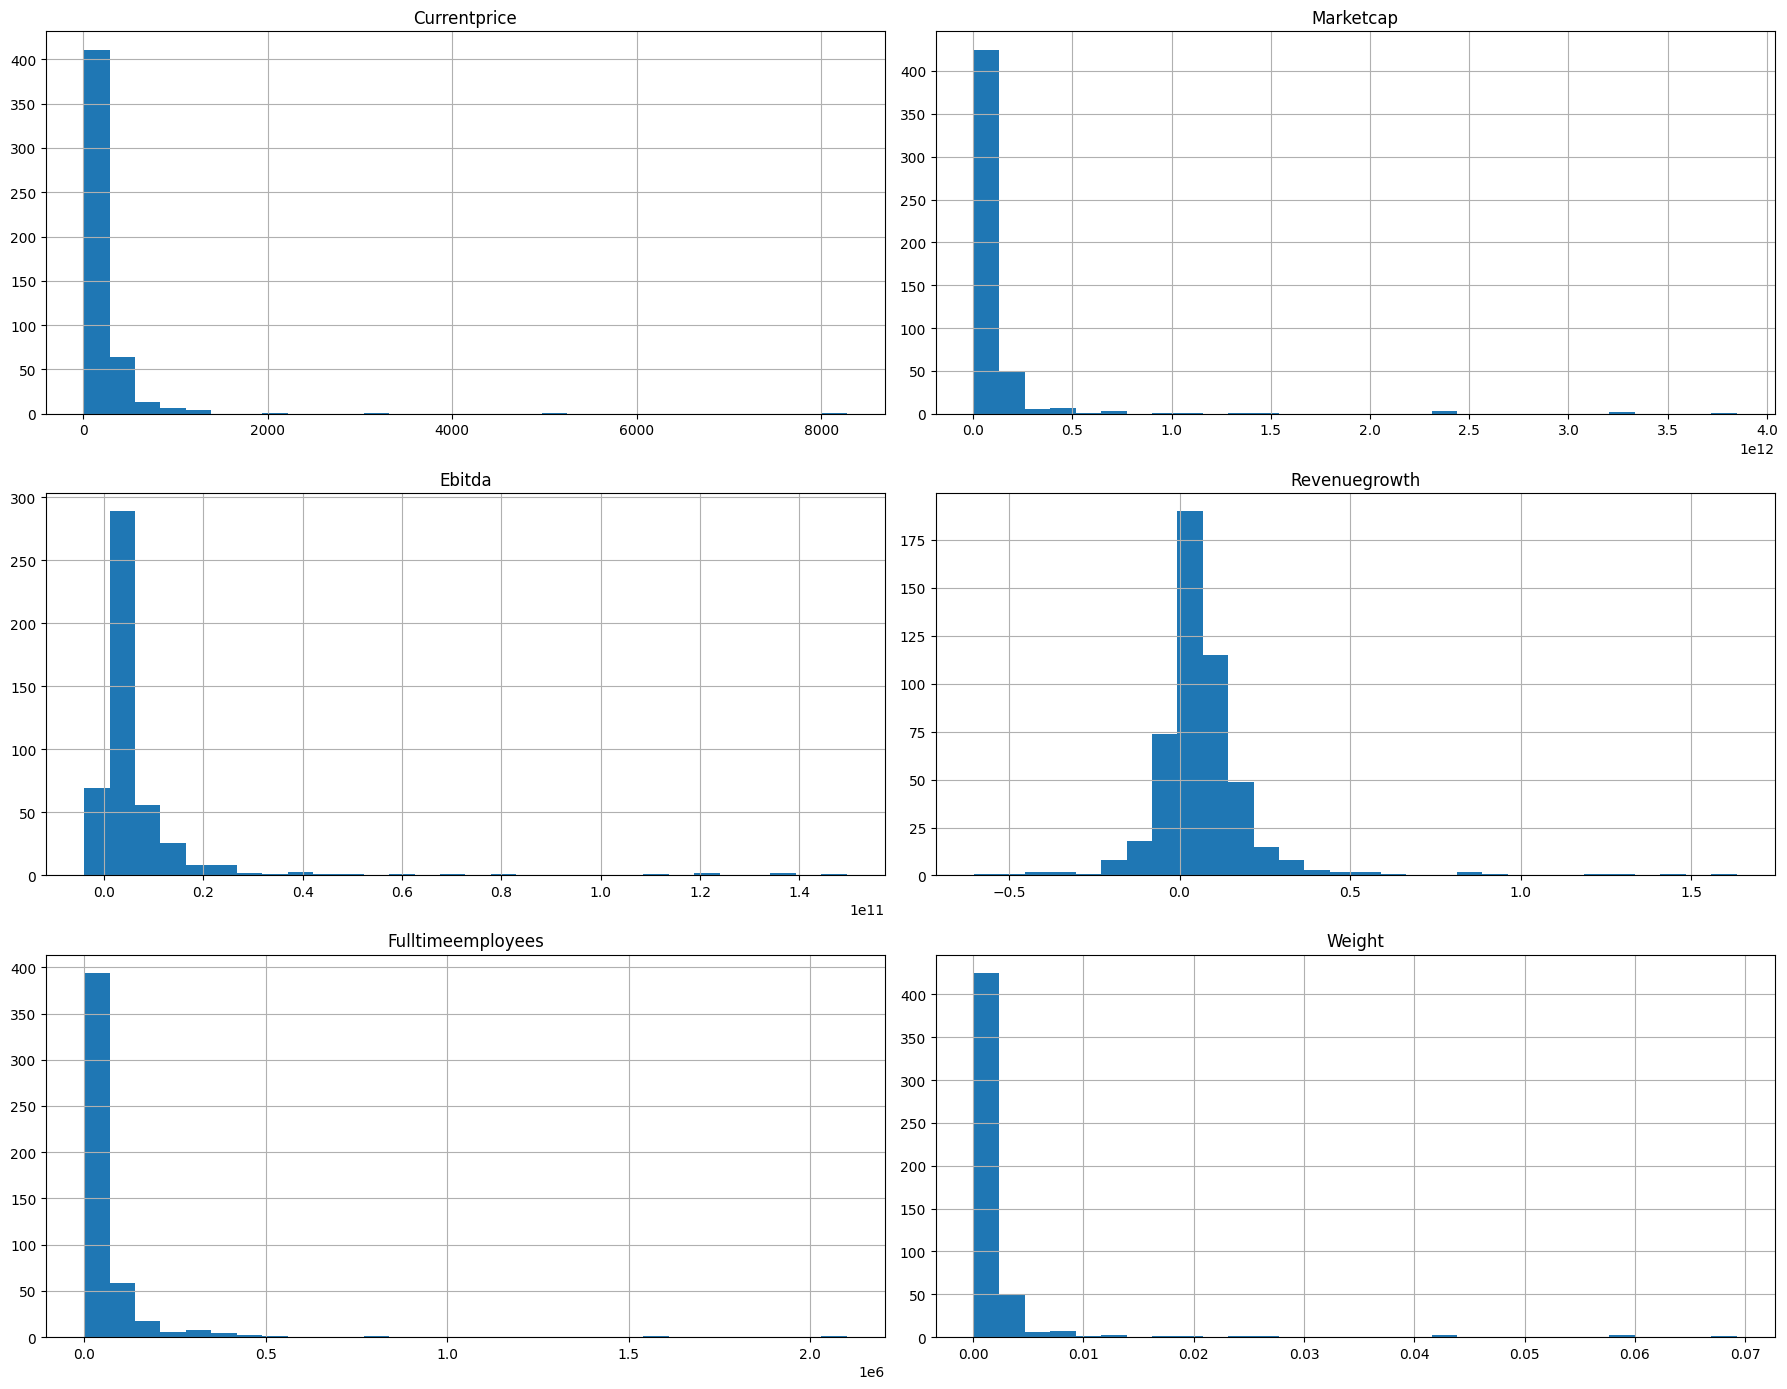

In [7]:
# Select only numeric columns for histogram plotting
numeric_cols = sp500_df.select_dtypes(include=['number']).columns

sp500_df[numeric_cols].hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

#Right Skew for all except revenue growth

**Log Transformed**

Applying log1p transformation to: ['Currentprice', 'Marketcap', 'Fulltimeemployees', 'Weight']


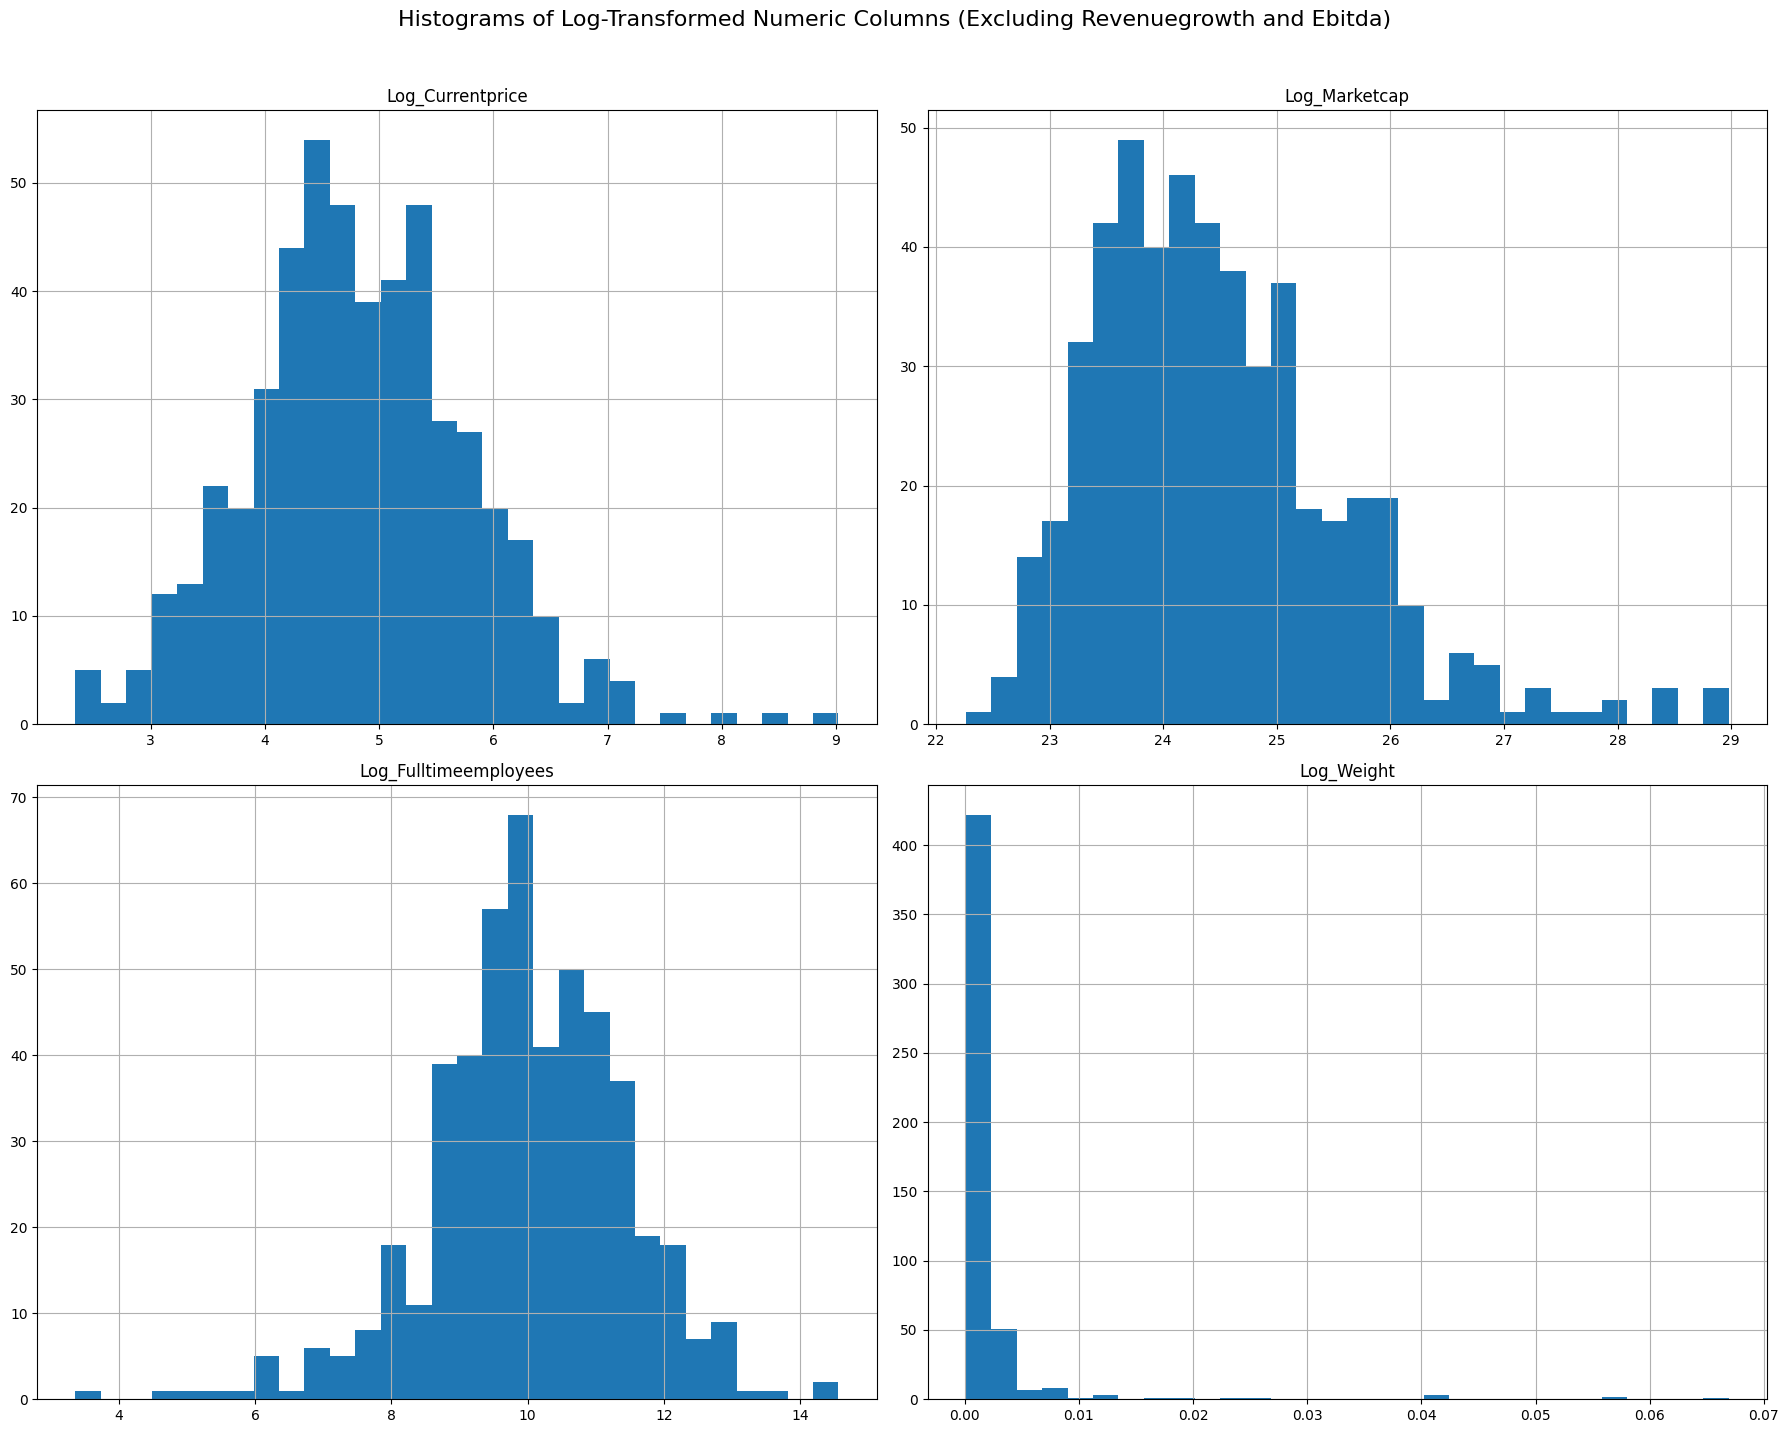

In [8]:
numeric_cols_original = sp500_df.select_dtypes(include=np.number).columns
exclude_cols = ['Revenuegrowth', 'Ebitda']


columns_to_transform = [col for col in numeric_cols_original if col not in exclude_cols]

print(f"Applying log1p transformation to: {columns_to_transform}")


sp500_df_transformed = sp500_df.copy()

for col in columns_to_transform:
    sp500_df_transformed[f'Log_{col}'] = np.log1p(sp500_df_transformed[col])

log_transformed_cols_for_plot = [col for col in sp500_df_transformed.columns if col.startswith('Log_')]

sp500_df_transformed[log_transformed_cols_for_plot].hist(figsize=(18, 14), bins=30)
plt.suptitle('Histograms of Log-Transformed Numeric Columns (Excluding Revenuegrowth and Ebitda)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()



#Full time employyes = left skew
#Market Cap = right skew
#Weight = Right Skew
#current Price = slight right skew

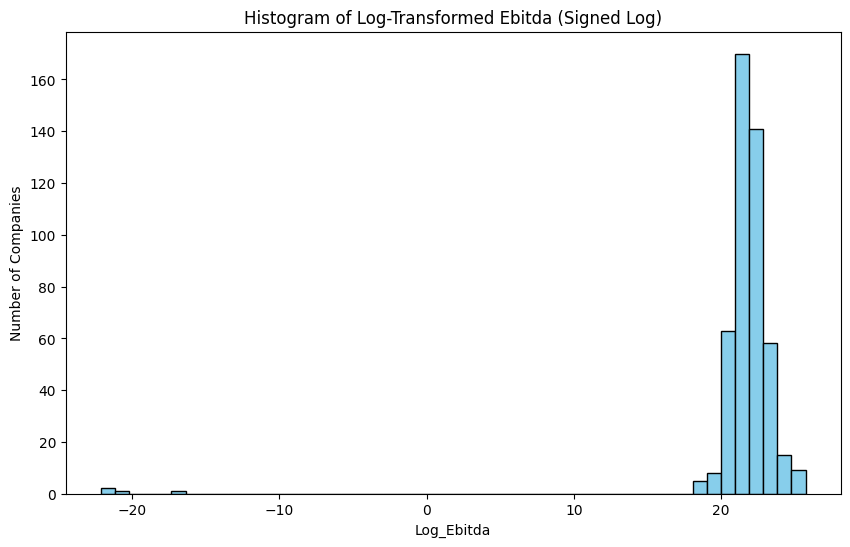

In [9]:
#ebitda
#it can't use normal log because it has negative Values
#Gemini suggestion was to use a signed log that can manage both positive and negative values

sp500_df_transformed['Log_Ebitda'] = np.sign(sp500_df_transformed['Ebitda']) * np.log1p(np.abs(sp500_df_transformed['Ebitda']))
plt.figure(figsize=(10,6))
plt.hist(sp500_df_transformed['Log_Ebitda'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Log-Transformed Ebitda (Signed Log)')
plt.xlabel('Log_Ebitda')
plt.ylabel('Number of Companies')
plt.show()

**Box Plot**

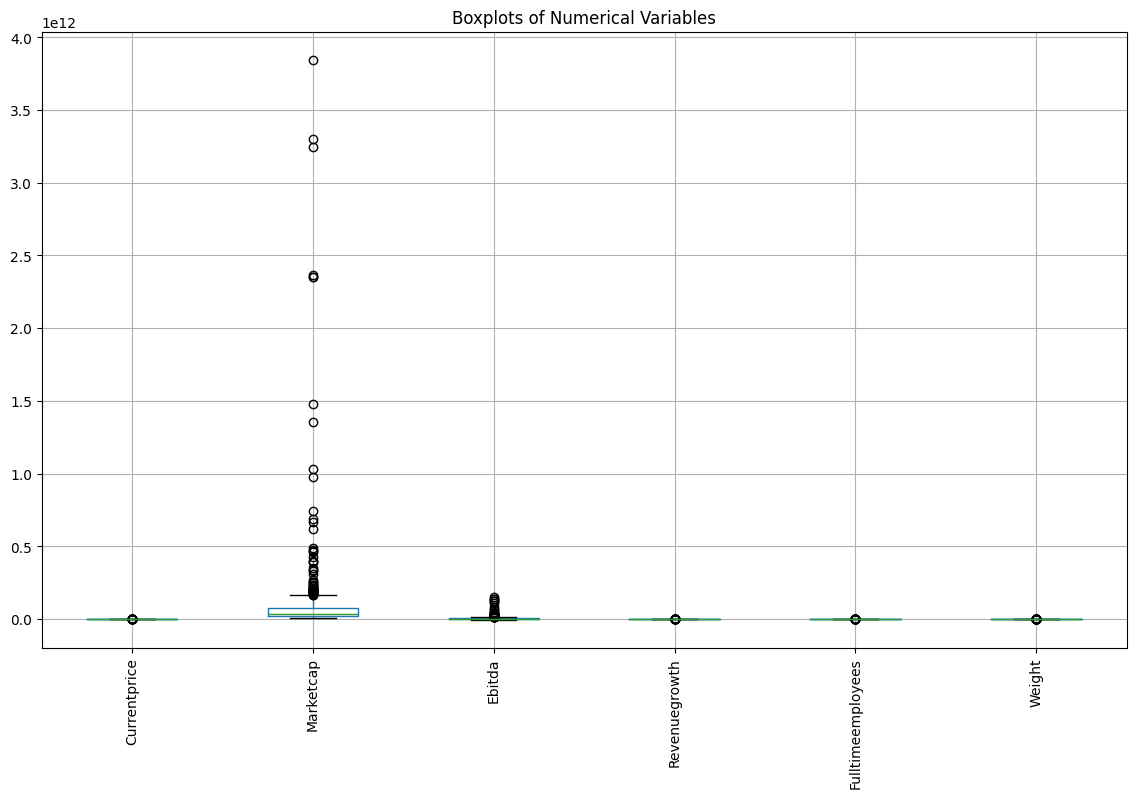

In [10]:
plt.figure(figsize=(14, 8))
sp500_df[numeric_cols].boxplot(rot=90)
plt.title("Boxplots of Numerical Variables")
plt.show()

#no significant difference in regular vs transformed
#plt.figure(figsize=(14, 8))
#sp500_df_transformed[numeric_cols].boxplot(rot=90)
#plt.title("Transformed Boxplots of Numerical Variables")
#plt.show()

#Market Place and Ebitda have the most number of outliers

**Correlation Matrix**

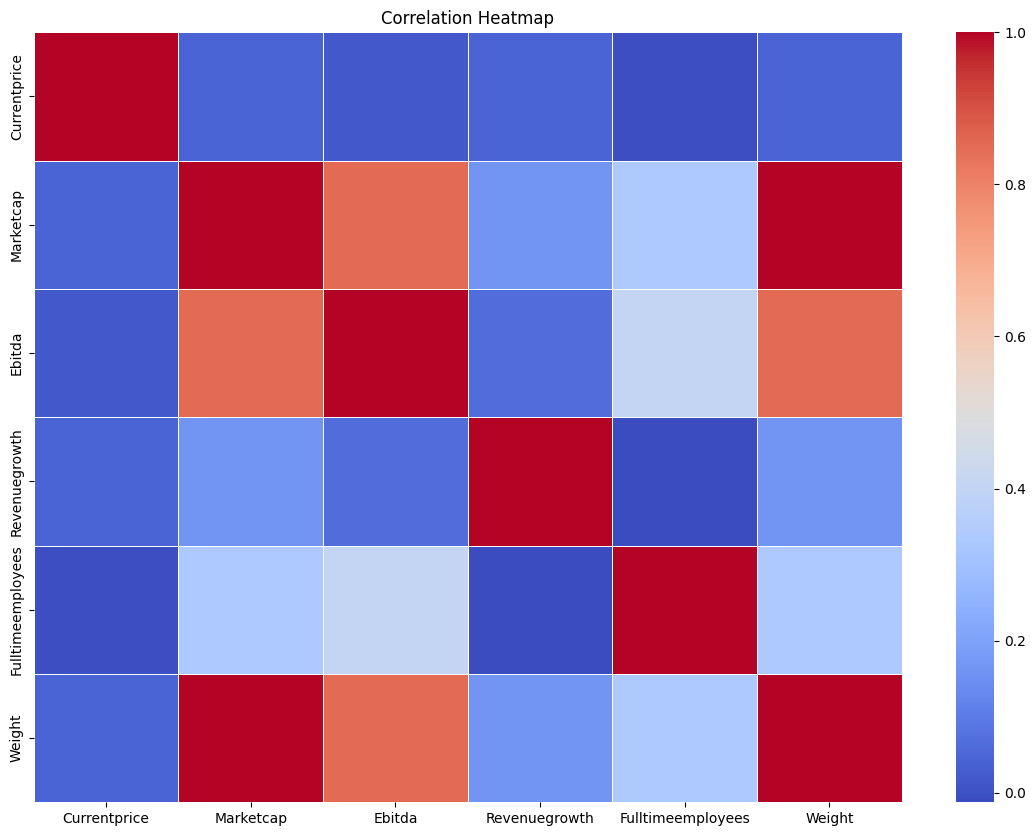

In [11]:
corr = sp500_df[numeric_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


#strongest correlation = Market Cap and Weight
#Moderate  = Market Cap and Ebitda , Ebitda and weight
#Lower = Full time employees and Ebitda



#no significant difference in regular vs transformed
#corr = sp500_df_transformed[numeric_cols].corr()

#plt.figure(figsize=(14,10))
#sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
#plt.title("Correlation Heatmap")
#plt.show()

##strongest correlation = Market Cap and Weight
#Moderate  = Market Cap and Ebitda, Ebitda and weight

#no real changes, specially revenue growth

In [12]:
sp500_df.isnull().sum()



,0
Exchange,0
Symbol,0
Shortname,0
Longname,0
Sector,0
Industry,0
Currentprice,0
Marketcap,0
Ebitda,29
Revenuegrowth,3


#Cleaning

In [13]:
cleaned_spf500_df = sp500_df.copy()

#State is categorical with missing values
# Weight is mostly zeros and highly correlated with Marketcap so it's almost redundant info
cleaned_spf500_df = cleaned_spf500_df.drop(columns=['Weight', 'State', 'City', 'Country', 'Longbusinesssummary'])


cleaned_spf500_df['Ebitda'] = cleaned_spf500_df['Ebitda'].fillna(cleaned_spf500_df['Ebitda'].median())
cleaned_spf500_df['Revenuegrowth'] = cleaned_spf500_df['Revenuegrowth'].fillna(cleaned_spf500_df['Revenuegrowth'].median())
cleaned_spf500_df['Fulltimeemployees'] = cleaned_spf500_df['Fulltimeemployees'].fillna(cleaned_spf500_df['Fulltimeemployees'].median())

cleaned_spf500_df.isnull().sum()


,0
Exchange,0
Symbol,0
Shortname,0
Longname,0
Sector,0
Industry,0
Currentprice,0
Marketcap,0
Ebitda,0
Revenuegrowth,0


#Preprocessing

In [14]:

#using log for Market, Current Price and Full time employees (I removed weight earlier)
#Ebitda will use signed log

for col in ['Marketcap', 'Currentprice', 'Fulltimeemployees']:
    cleaned_spf500_df['Log_' + col] = np.log1p(cleaned_spf500_df[col])

cleaned_spf500_df['Signed_Log_Ebitda'] = np.sign(cleaned_spf500_df['Ebitda']) * np.log1p(np.abs(cleaned_spf500_df['Ebitda']))

cols_for_clustering = ['Log_Marketcap', 'Signed_Log_Ebitda', 'Log_Currentprice', 'Log_Fulltimeemployees', 'Revenuegrowth']
spf500_clustering = cleaned_spf500_df[cols_for_clustering]

print("Transformed DataFrame (cleaned_spf500_df) head:")
display(cleaned_spf500_df.head())

print("\nClustering DataFrame (spf500_clustering) head:")
display(spf500_clustering.head())

Transformed DataFrame (cleaned_spf500_df) head:


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Log_Marketcap,Log_Currentprice,Log_Fulltimeemployees,Signed_Log_Ebitda
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,164000.0,28.978268,5.543183,12.007628,25.626026
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,29600.0,28.824581,4.910447,10.295563,24.837152
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,228000.0,28.808466,6.081305,12.337105,25.639971
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,1551000.0,28.491813,5.420181,14.254411,25.438035
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,181269.0,28.486128,5.259629,12.107743,25.539264



Clustering DataFrame (spf500_clustering) head:


,Log_Marketcap,Signed_Log_Ebitda,Log_Currentprice,Log_Fulltimeemployees,Revenuegrowth
0,28.978268,25.626026,5.543183,12.007628,0.061
1,28.824581,24.837152,4.910447,10.295563,1.224
2,28.808466,25.639971,6.081305,12.337105,0.160
3,28.491813,25.438035,5.420181,14.254411,0.110
4,28.486128,25.539264,5.259629,12.107743,0.151


In [15]:
#standardizing

scaler = StandardScaler()

spf500_clean_scaled_df = pd.DataFrame(scaler.fit_transform(spf500_clustering),
                             columns=spf500_clustering.columns)
print("Scaled Df:")
display(spf500_clean_scaled_df.head())

#check



Scaled Df:


,Log_Marketcap,Signed_Log_Ebitda,Log_Currentprice,Log_Fulltimeemployees,Revenuegrowth
0,4.053810,1.040488,0.741164,1.399547,-0.052493
1,3.915249,0.838349,0.086468,0.200104,6.425399
2,3.900720,1.044062,1.297961,1.630374,0.498935
3,3.615233,0.992318,0.613893,2.973605,0.220436
4,3.610107,1.018257,0.447768,1.469686,0.448805


#Clustering before PCA

##K-Means Clustering (pre PCA)

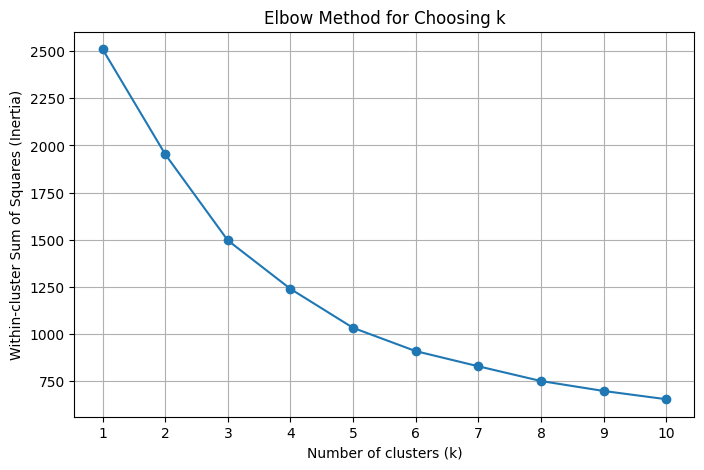

In [16]:

k_values = range(1, 11)
inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans.fit(spf500_clean_scaled_df)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster Sum of Squares (Inertia)')
plt.title('Elbow Method for Choosing k')
plt.xticks(k_values)
plt.grid(True)
plt.show()


In [17]:
#Selecting K =4 based on the elbow method


kmeans = KMeans(n_clusters=4, n_init=10, random_state=0)
kmeans.fit(spf500_clean_scaled_df)

cluster_labels = pd.Series(kmeans.labels_, index=spf500_clean_scaled_df.index, name='Cluster')
print("Cluster membership:")
for cluster, data in cluster_labels.groupby(cluster_labels):
    print(f"Cluster {cluster}: {', '.join([str(idx) for idx in data.index[:10]])} ...")

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=spf500_clean_scaled_df.columns)
pd.set_option('display.precision', 3)
print("\nCluster centroids (scaled features):")
display(centroids)



#Distance to centroids see how far each company is from the supposed “center” of its cluster
# A way to see how well the clusters represent the data.
distances = kmeans.transform(spf500_clean_scaled_df)
min_squared_distances = distances.min(axis=1) ** 2
distance_df = pd.DataFrame({'squaredDistance': min_squared_distances, 'cluster': kmeans.labels_},
                           index=spf500_clean_scaled_df.index)

# Within-cluster sum of squares
#Adding the squared distances for each cluster to see how tight or spread out the cluster members are
# Another way to see how well the clustering is working.
for cluster, data in distance_df.groupby('cluster'):
    count = len(data)
    within_ss = data.squaredDistance.sum()
    print(f"Cluster {cluster} ({count} members): {within_ss:.2f} within-cluster sum of squares")

Cluster membership:
Cluster 0: 48, 66, 81, 98, 100, 101, 108, 109, 115, 117 ...
Cluster 1: 0, 2, 3, 4, 5, 6, 7, 8, 9, 10 ...
Cluster 2: 1, 96, 215, 223, 307, 341, 384 ...
Cluster 3: 77, 392, 423, 471 ...

Cluster centroids (scaled features):


,Log_Marketcap,Signed_Log_Ebitda,Log_Currentprice,Log_Fulltimeemployees,Revenuegrowth
0,-0.547,-0.029,-0.347,-0.398,-0.179
1,0.965,0.285,0.644,0.701,0.106
2,0.421,0.233,-0.511,0.169,6.159
3,-0.499,-10.707,-0.406,-0.063,-1.446


Cluster 0 (314 members): 721.58 within-cluster sum of squares
Cluster 1 (177 members): 464.64 within-cluster sum of squares
Cluster 2 (7 members): 39.28 within-cluster sum of squares
Cluster 3 (4 members): 13.59 within-cluster sum of squares


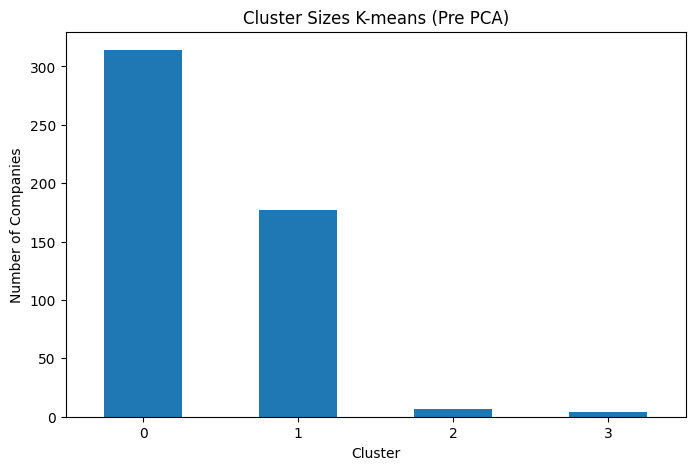

In [18]:
# Attach K-Means labels to the scaled DataFrame for plotting
spf500_scaled_with_labels = spf500_clean_scaled_df.copy()
spf500_scaled_with_labels['cluster'] = kmeans.labels_

# Cluster Sizes
plt.figure(figsize=(8, 5))
spf500_scaled_with_labels['cluster'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Sizes K-means (Pre PCA)")
plt.xlabel("Cluster")
plt.ylabel("Number of Companies")
plt.xticks(rotation=0)
plt.show()

### Cluster Profiling: Pre-PCA K-Means (k=4)

In [19]:

cleaned_spf500_df_with_k4_pre_pca = cleaned_spf500_df.copy()
cleaned_spf500_df_with_k4_pre_pca['Cluster_k4_PrePCA'] = kmeans.labels_

print("DataFrame with Pre-PCA K-Means (k=4) Cluster Labels head:")
display(cleaned_spf500_df_with_k4_pre_pca.head())

DataFrame with Pre-PCA K-Means (k=4) Cluster Labels head:


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Log_Marketcap,Log_Currentprice,Log_Fulltimeemployees,Signed_Log_Ebitda,Cluster_k4_PrePCA
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.347e+11,0.061,1.640e+05,28.978,5.543,12.008,25.626,1
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118e+10,1.224,2.960e+04,28.825,4.910,10.296,24.837,2
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.366e+11,0.160,2.280e+05,28.808,6.081,12.337,25.640,1
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.116e+11,0.110,1.551e+06,28.492,5.420,14.254,25.438,1
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.235e+11,0.151,1.813e+05,28.486,5.260,12.108,25.539,1


#### Sector Distribution (Pre-PCA K-Means, k=4)


Sector Distribution per Cluster (Pre-PCA K-Means, k=4 - Top 5):

Cluster 0:


,Cluster_k4_PrePCA,Sector,Percentage
0,0,Technology,14.331
1,0,Industrials,12.739
2,0,Consumer Cyclical,10.828
3,0,Financial Services,10.191
4,0,Healthcare,10.191



Cluster 1:


,Cluster_k4_PrePCA,Sector,Percentage
11,1,Technology,19.209
12,1,Financial Services,18.079
13,1,Healthcare,16.384
14,1,Industrials,16.384
15,1,Consumer Cyclical,11.299



Cluster 2:


,Cluster_k4_PrePCA,Sector,Percentage
22,2,Technology,42.857
23,2,Financial Services,28.571
24,2,Basic Materials,14.286
25,2,Consumer Cyclical,14.286



Cluster 3:


,Cluster_k4_PrePCA,Sector,Percentage
26,3,Basic Materials,25.0
27,3,Financial Services,25.0
28,3,Healthcare,25.0
29,3,Industrials,25.0


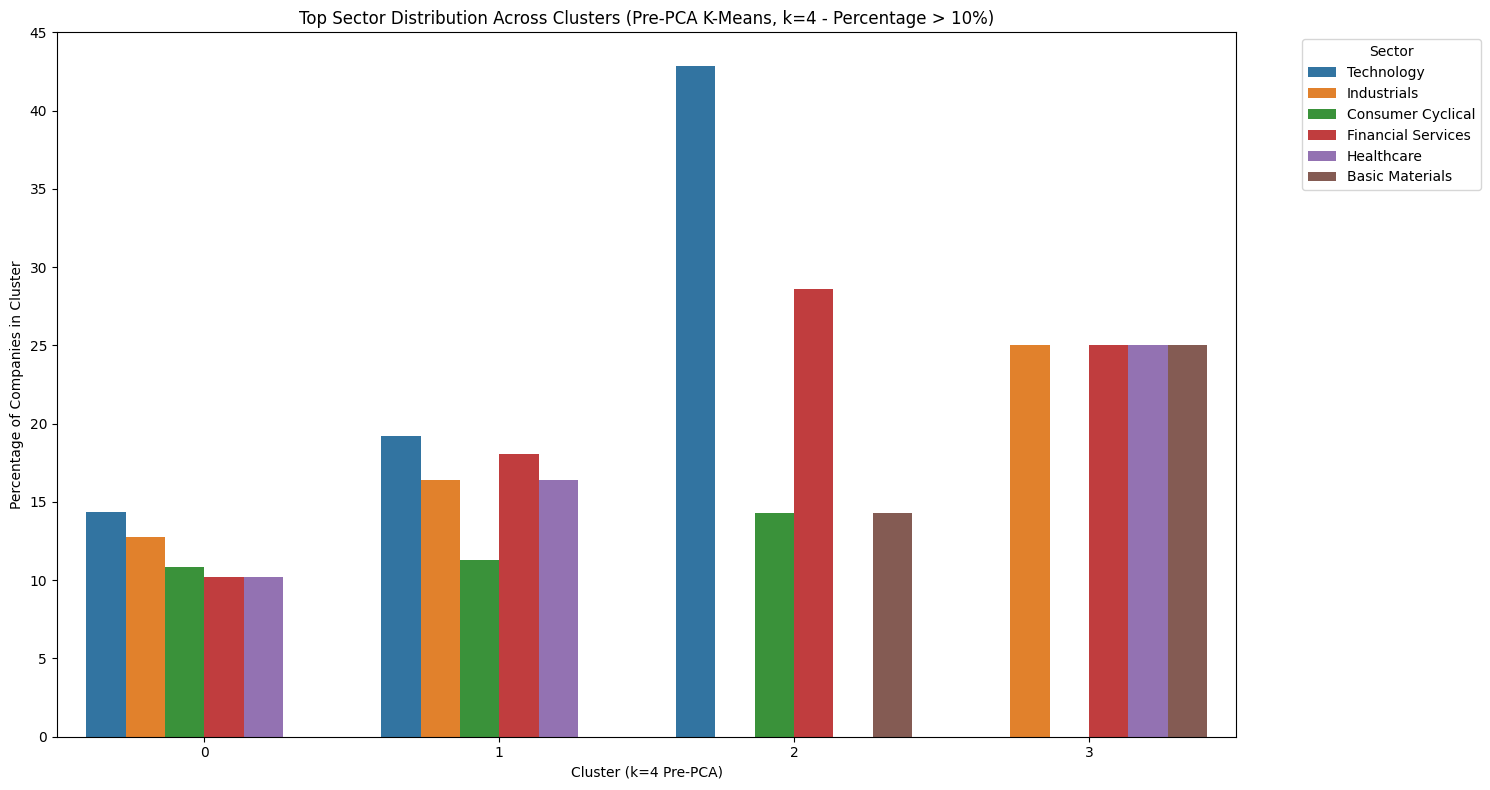

In [20]:

print("\nSector Distribution per Cluster (Pre-PCA K-Means, k=4 - Top 5):")
sector_profiling_k4_pre_pca = cleaned_spf500_df_with_k4_pre_pca.groupby('Cluster_k4_PrePCA')['Sector'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_k4_pre_pca['Cluster_k4_PrePCA'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(sector_profiling_k4_pre_pca[sector_profiling_k4_pre_pca['Cluster_k4_PrePCA'] == cluster_id].head(5))

plt.figure(figsize=(15, 8))
sns.barplot(data=sector_profiling_k4_pre_pca[sector_profiling_k4_pre_pca['Percentage'] > 10], x='Cluster_k4_PrePCA', y='Percentage', hue='Sector', palette='tab10')
plt.title('Top Sector Distribution Across Clusters (Pre-PCA K-Means, k=4 - Percentage > 10%)')
plt.xlabel('Cluster (k=4 Pre-PCA)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Industry Distribution (Pre-PCA K-Means, k=4)


Industry Distribution per Cluster (Pre-PCA K-Means, k=4 - Top 5):

Cluster 0:


,Cluster_k4_PrePCA,Industry,Percentage
0,0,Utilities - Regulated Electric,6.369
1,0,Specialty Industrial Machinery,3.503
2,0,Oil & Gas E&P,3.185
3,0,Packaged Foods,2.866
4,0,Banks - Regional,2.548



Cluster 1:


,Cluster_k4_PrePCA,Industry,Percentage
102,1,Software - Application,5.085
103,1,Drug Manufacturers - General,4.520
104,1,Aerospace & Defense,3.955
105,1,Credit Services,3.390
106,1,Semiconductors,3.390



Cluster 2:


,Cluster_k4_PrePCA,Industry,Percentage
167,2,Semiconductors,28.571
168,2,Computer Hardware,14.286
169,2,Gold,14.286
170,2,Insurance - Life,14.286
171,2,Insurance - Property & Casualty,14.286



Cluster 3:


,Cluster_k4_PrePCA,Industry,Percentage
173,3,Aerospace & Defense,25.0
174,3,Asset Management,25.0
175,3,Biotechnology,25.0
176,3,Specialty Chemicals,25.0


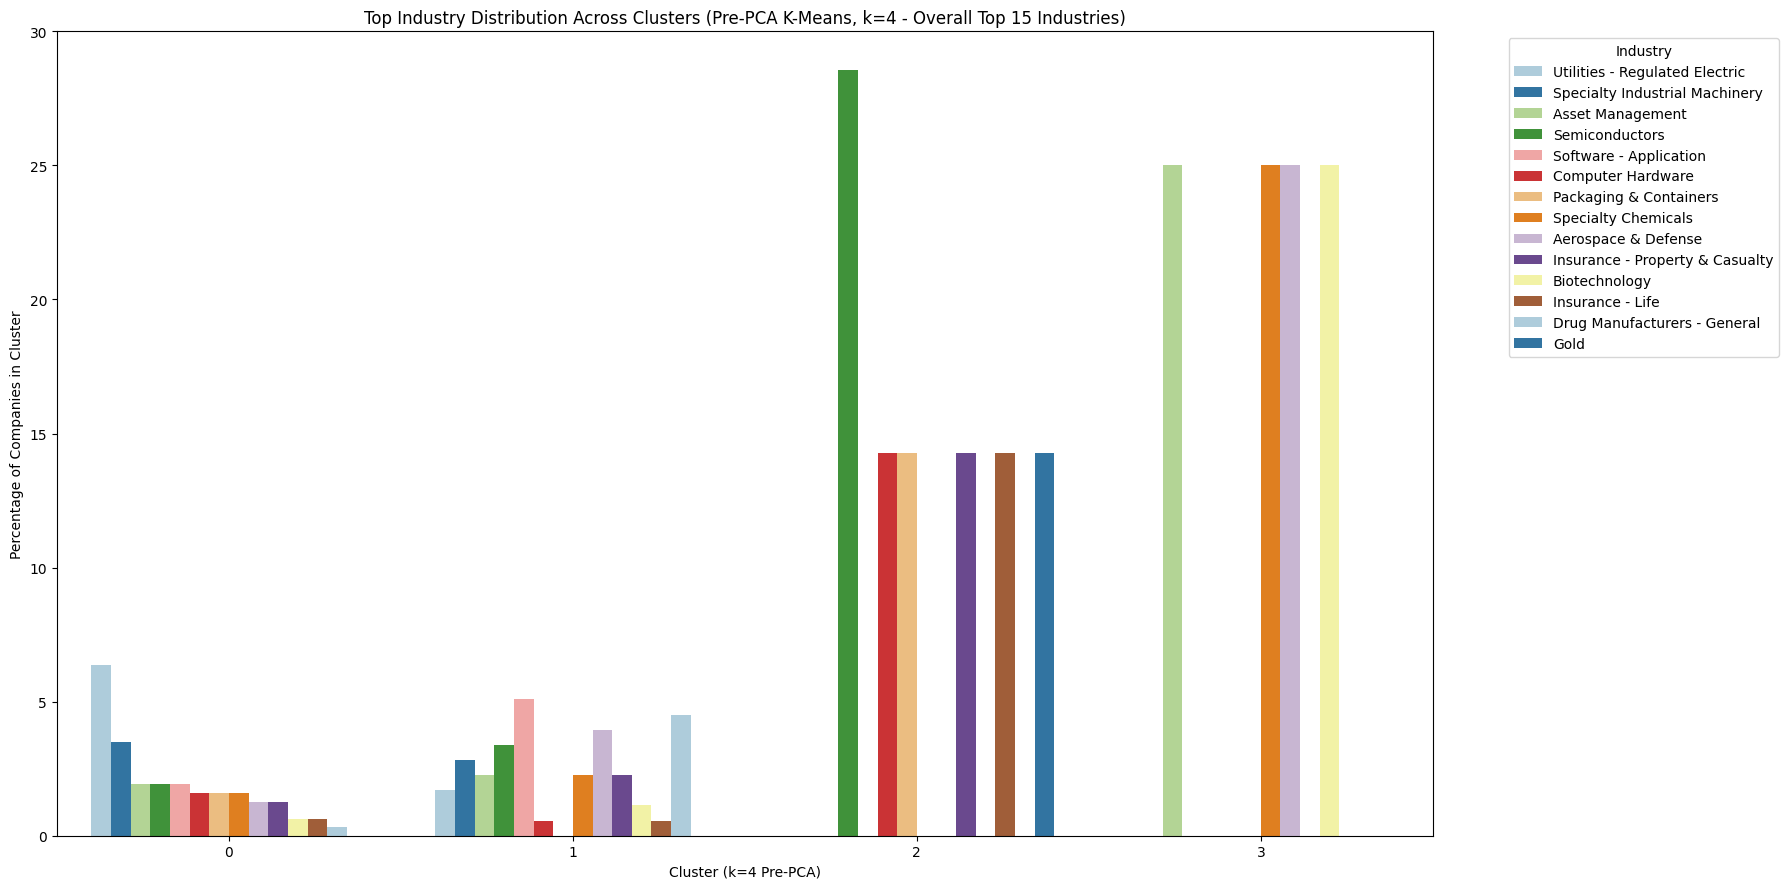

In [21]:
print("\nIndustry Distribution per Cluster (Pre-PCA K-Means, k=4 - Top 5):")
industry_profiling_k4_pre_pca = cleaned_spf500_df_with_k4_pre_pca.groupby('Cluster_k4_PrePCA')['Industry'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_k4_pre_pca['Cluster_k4_PrePCA'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(industry_profiling_k4_pre_pca[industry_profiling_k4_pre_pca['Cluster_k4_PrePCA'] == cluster_id].head(5))


top_industries_k4_pre_pca = industry_profiling_k4_pre_pca.nlargest(15, 'Percentage')['Industry'].unique()
plt.figure(figsize=(18, 9))
sns.barplot(data=industry_profiling_k4_pre_pca[industry_profiling_k4_pre_pca['Industry'].isin(top_industries_k4_pre_pca)], x='Cluster_k4_PrePCA', y='Percentage', hue='Industry', palette='Paired')
plt.title('Top Industry Distribution Across Clusters (Pre-PCA K-Means, k=4 - Overall Top 15 Industries)')
plt.xlabel('Cluster (k=4 Pre-PCA)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##Hierarchial Clustering  (pre PCA)

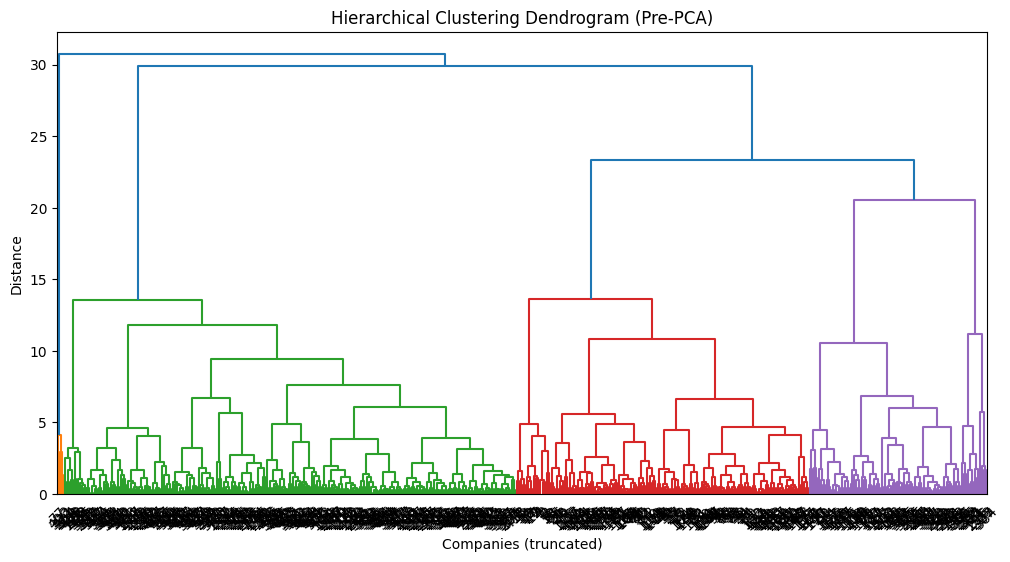

In [22]:
Z = linkage(spf500_clean_scaled_df, method='ward')

#Plot
plt.figure(figsize=(12, 6))
plt.title('Hierarchical Clustering Dendrogram (Pre-PCA)')
dendrogram(Z, truncate_mode='level', p=20, leaf_rotation=45, leaf_font_size=10)
plt.xlabel('Companies (truncated)')
plt.ylabel('Distance')
plt.show()

The largest vertical jumps that I can see occur at around distances 24-30, showing where very dissimilar clusters merge. If I Cut the dendrogram at around 12, it splits the data into four distinct clusters, which matches the natural separation we see.

In [23]:
#cluster labelling

hc_labels = fcluster(Z, 4, criterion='maxclust')
hc_membership = pd.Series(hc_labels, index=spf500_clean_scaled_df.index, name='Cluster')

for key, item in hc_membership.groupby(hc_membership):
    print(f"Cluster {key}: {', '.join(map(str, item.index))}")

#Cluster centroids
hc_centroids = spf500_clean_scaled_df.groupby(hc_membership).mean()
pd.set_option('display.precision', 3)
print("\nHierarchical cluster centroids (scaled features):")
display(hc_centroids)

#Witin cluster sum of Squares
distances = pairwise.pairwise_distances(spf500_clean_scaled_df, hc_centroids.loc[hc_membership])
min_squared_distances = distances.min(axis=1) ** 2
distance_df = pd.DataFrame({'squaredDistance': min_squared_distances, 'cluster': hc_membership},
                           index=spf500_clean_scaled_df.index)

for cluster, data in distance_df.groupby('cluster'):
    count = len(data)
    within_ss = data.squaredDistance.sum()
    print(f"Cluster {cluster} ({count} members): {within_ss:.2f} within-cluster sum of squares")




Cluster 1: 77, 392, 423, 471
Cluster 2: 92, 101, 126, 154, 160, 164, 166, 167, 172, 175, 176, 188, 189, 191, 200, 201, 202, 204, 205, 206, 209, 210, 212, 214, 217, 219, 220, 221, 222, 224, 226, 229, 231, 233, 238, 239, 240, 242, 244, 246, 248, 249, 250, 251, 252, 255, 256, 257, 259, 262, 263, 265, 266, 267, 269, 272, 273, 274, 276, 277, 278, 279, 280, 281, 282, 283, 284, 286, 287, 290, 291, 293, 294, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 308, 309, 310, 311, 313, 315, 317, 318, 319, 320, 321, 323, 324, 325, 326, 327, 330, 331, 332, 333, 334, 335, 336, 338, 339, 340, 342, 343, 345, 346, 347, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 365, 367, 369, 370, 372, 373, 374, 375, 376, 377, 378, 380, 383, 388, 389, 391, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 424, 425, 426, 427, 428, 429, 430, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 444, 445, 446, 4

,Log_Marketcap,Signed_Log_Ebitda,Log_Currentprice,Log_Fulltimeemployees,Revenuegrowth
Cluster,,,,,
1,-0.499,-10.707,-0.406,-0.063,-1.446
2,-0.649,-0.031,-0.537,-0.320,-0.304
3,0.956,0.332,0.290,0.917,-0.006
4,0.096,-0.022,0.906,-0.693,0.843


Cluster 1 (4 members): 13.59 within-cluster sum of squares
Cluster 2 (244 members): 451.72 within-cluster sum of squares
Cluster 3 (158 members): 331.23 within-cluster sum of squares
Cluster 4 (96 members): 490.05 within-cluster sum of squares


### Cluster Profiling: Pre-PCA Hierarchical (k=4)

In [24]:
# Attach pre-PCA Hierarchical (k=4) labels to the cleaned DataFrame
# The 'hc_membership' Series from cell lvGEcC54ll3C contains the pre-PCA k=4 labels
cleaned_spf500_df_with_hc4_pre_pca = cleaned_spf500_df.copy()
cleaned_spf500_df_with_hc4_pre_pca['Cluster_k4_PrePCA_HC'] = hc_membership

print("DataFrame with Pre-PCA Hierarchical (k=4) Cluster Labels head:")
display(cleaned_spf500_df_with_hc4_pre_pca.head())

DataFrame with Pre-PCA Hierarchical (k=4) Cluster Labels head:


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Log_Marketcap,Log_Currentprice,Log_Fulltimeemployees,Signed_Log_Ebitda,Cluster_k4_PrePCA_HC
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.347e+11,0.061,1.640e+05,28.978,5.543,12.008,25.626,3
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118e+10,1.224,2.960e+04,28.825,4.910,10.296,24.837,4
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.366e+11,0.160,2.280e+05,28.808,6.081,12.337,25.640,3
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.116e+11,0.110,1.551e+06,28.492,5.420,14.254,25.438,3
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.235e+11,0.151,1.813e+05,28.486,5.260,12.108,25.539,3


#### Sector Distribution (Pre-PCA Hierarchical, k=4)


Sector Distribution per Cluster (Pre-PCA Hierarchical, k=4 - Top 5):

Cluster 1:


,Cluster_k4_PrePCA_HC,Sector,Percentage
0,1,Basic Materials,25.0
1,1,Financial Services,25.0
2,1,Healthcare,25.0
3,1,Industrials,25.0



Cluster 2:


,Cluster_k4_PrePCA_HC,Sector,Percentage
4,2,Industrials,12.705
5,2,Technology,12.705
6,2,Consumer Cyclical,11.885
7,2,Healthcare,10.656
8,2,Utilities,10.656



Cluster 3:


,Cluster_k4_PrePCA_HC,Sector,Percentage
15,3,Industrials,18.354
16,3,Financial Services,17.089
17,3,Healthcare,16.456
18,3,Technology,15.190
19,3,Consumer Cyclical,10.759



Cluster 4:


,Cluster_k4_PrePCA_HC,Sector,Percentage
26,4,Technology,28.125
27,4,Financial Services,18.750
28,4,Real Estate,11.458
29,4,Consumer Cyclical,9.375
30,4,Healthcare,9.375


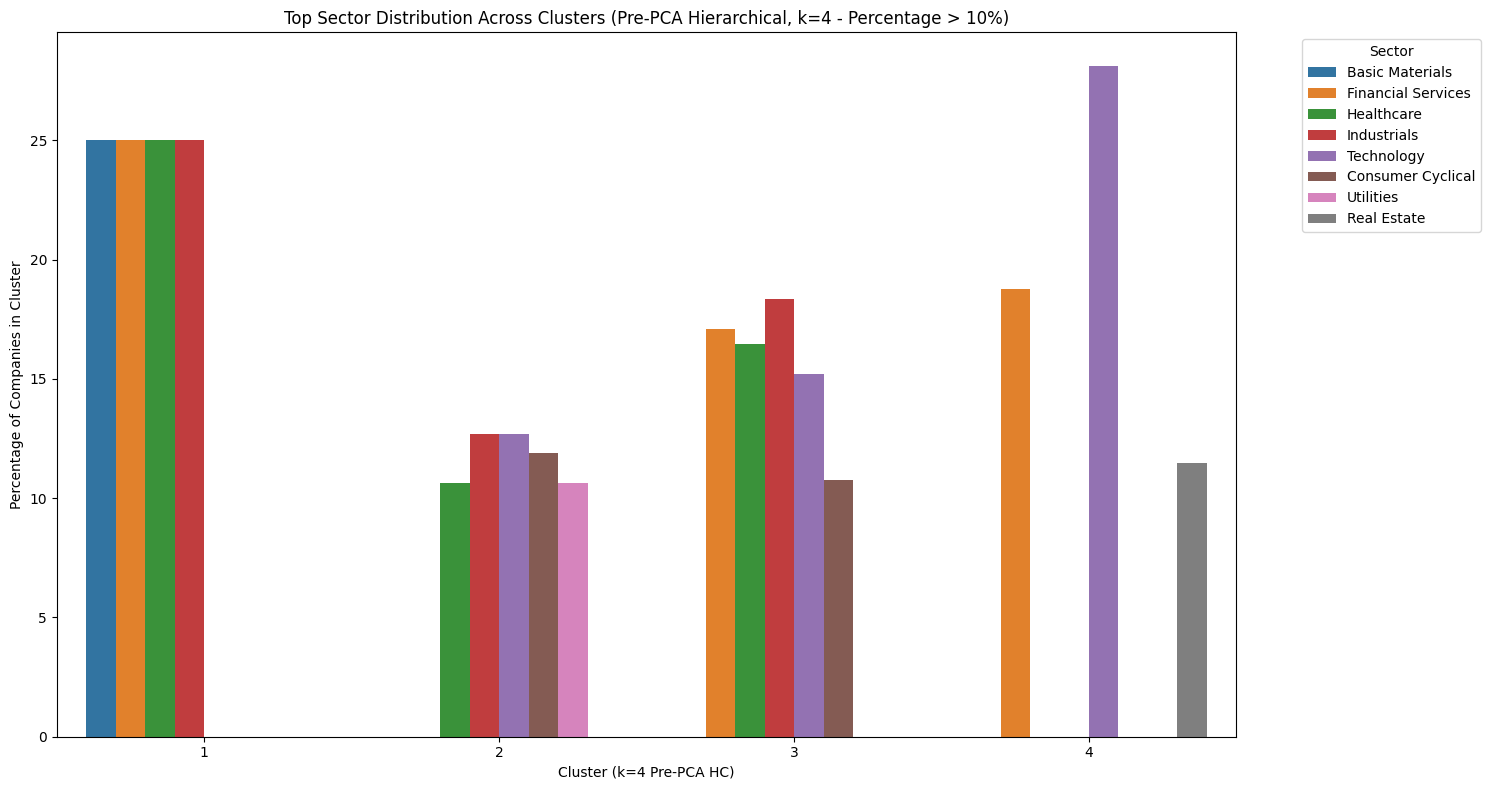

In [25]:
print("\nSector Distribution per Cluster (Pre-PCA Hierarchical, k=4 - Top 5):")
sector_profiling_hc4_pre_pca = cleaned_spf500_df_with_hc4_pre_pca.groupby('Cluster_k4_PrePCA_HC')['Sector'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_hc4_pre_pca['Cluster_k4_PrePCA_HC'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(sector_profiling_hc4_pre_pca[sector_profiling_hc4_pre_pca['Cluster_k4_PrePCA_HC'] == cluster_id].head(5))


plt.figure(figsize=(15, 8))
sns.barplot(data=sector_profiling_hc4_pre_pca[sector_profiling_hc4_pre_pca['Percentage'] > 10], x='Cluster_k4_PrePCA_HC', y='Percentage', hue='Sector', palette='tab10')
plt.title('Top Sector Distribution Across Clusters (Pre-PCA Hierarchical, k=4 - Percentage > 10%)')
plt.xlabel('Cluster (k=4 Pre-PCA HC)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Industry Distribution (Pre-PCA Hierarchical, k=4)


Industry Distribution per Cluster (Pre-PCA Hierarchical, k=4 - Top 5):

Cluster 1:


,Cluster_k4_PrePCA_HC,Industry,Percentage
0,1,Aerospace & Defense,25.0
1,1,Asset Management,25.0
2,1,Biotechnology,25.0
3,1,Specialty Chemicals,25.0



Cluster 2:


,Cluster_k4_PrePCA_HC,Industry,Percentage
4,2,Utilities - Regulated Electric,8.197
5,2,Specialty Industrial Machinery,4.098
6,2,Packaged Foods,3.689
7,2,Banks - Regional,2.869
8,2,Entertainment,2.869



Cluster 3:


,Cluster_k4_PrePCA_HC,Industry,Percentage
96,3,Drug Manufacturers - General,5.063
97,3,Aerospace & Defense,3.797
98,3,Healthcare Plans,3.797
99,3,Information Technology Services,3.797
100,3,Semiconductors,3.797



Cluster 4:


,Cluster_k4_PrePCA_HC,Industry,Percentage
160,4,Software - Application,8.333
161,4,Financial Data & Stock Exchanges,7.292
162,4,Software - Infrastructure,7.292
163,4,Asset Management,4.167
164,4,Oil & Gas E&P,4.167


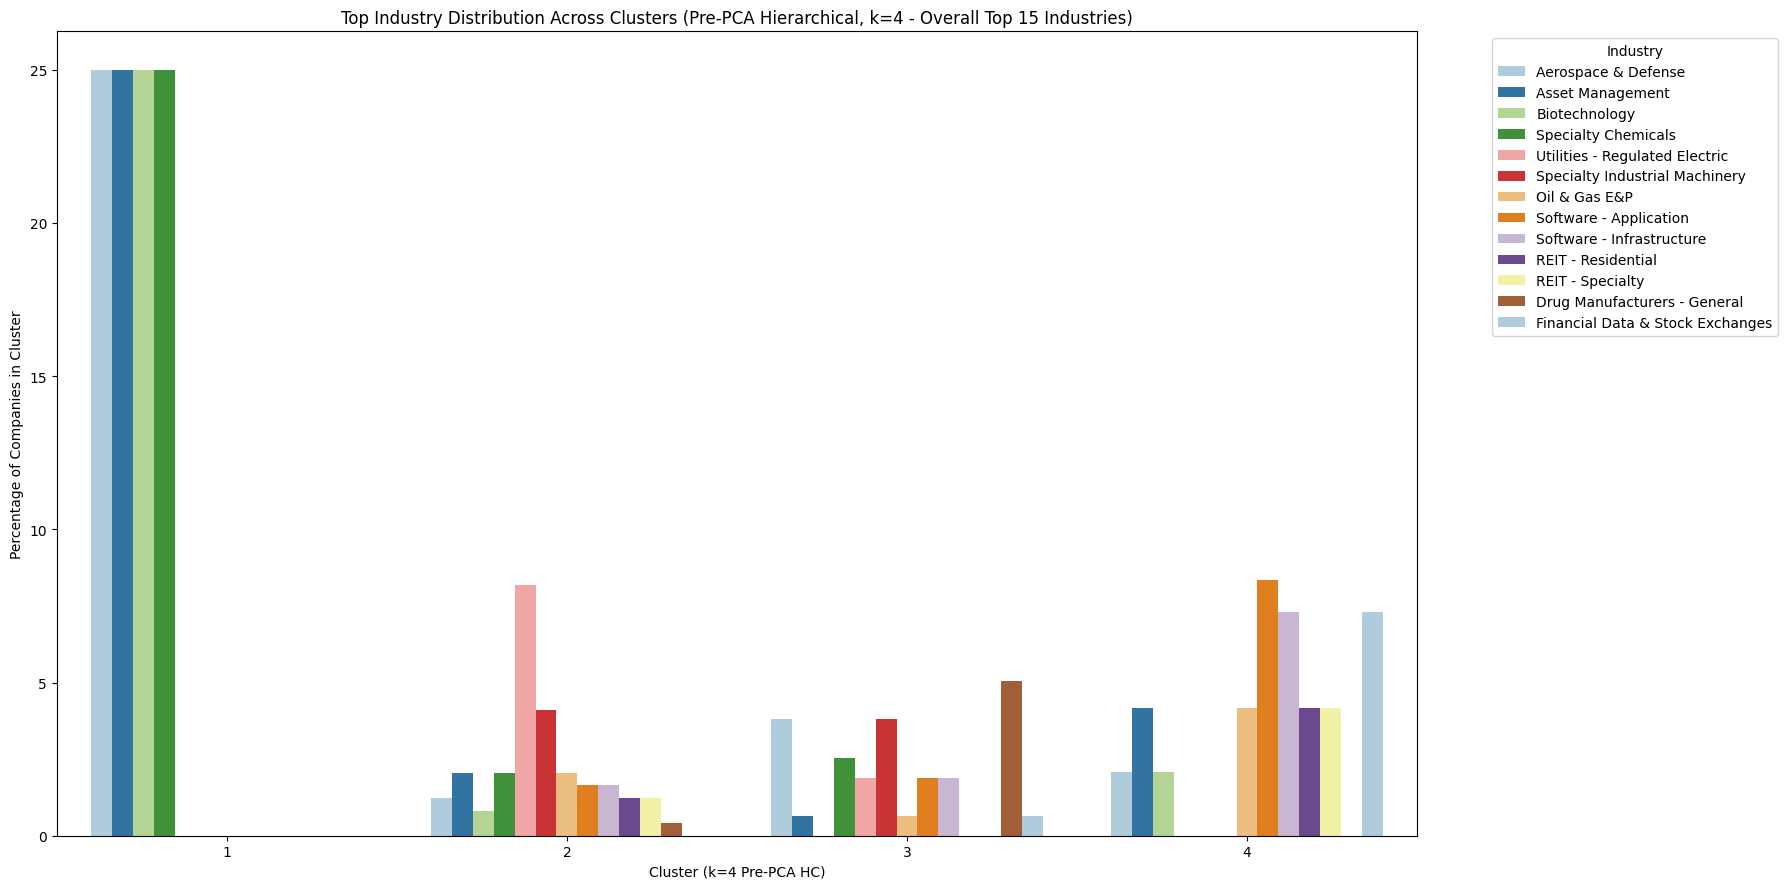

In [26]:
print("\nIndustry Distribution per Cluster (Pre-PCA Hierarchical, k=4 - Top 5):")
industry_profiling_hc4_pre_pca = cleaned_spf500_df_with_hc4_pre_pca.groupby('Cluster_k4_PrePCA_HC')['Industry'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_hc4_pre_pca['Cluster_k4_PrePCA_HC'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(industry_profiling_hc4_pre_pca[industry_profiling_hc4_pre_pca['Cluster_k4_PrePCA_HC'] == cluster_id].head(5))


top_industries_hc4_pre_pca = industry_profiling_hc4_pre_pca.nlargest(15, 'Percentage')['Industry'].unique()
plt.figure(figsize=(18, 9))
sns.barplot(data=industry_profiling_hc4_pre_pca[industry_profiling_hc4_pre_pca['Industry'].isin(top_industries_hc4_pre_pca)], x='Cluster_k4_PrePCA_HC', y='Percentage', hue='Industry', palette='Paired')
plt.title('Top Industry Distribution Across Clusters (Pre-PCA Hierarchical, k=4 - Overall Top 15 Industries)')
plt.xlabel('Cluster (k=4 Pre-PCA HC)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#PCA

In [27]:
from sklearn.decomposition import PCA

# Store pca results
pca_results = {}
spf500_pca_90 = None # Initialize
spf500_pca_90_df = None # Initialize

for thresh in [0.80, 0.90, 0.95]:
    pca = PCA(n_components=thresh)
    pca_transformed = pca.fit_transform(spf500_clean_scaled_df)
    pca_results[thresh] = pd.DataFrame(pca_transformed)
    print(int(thresh*100), "% variance -> components:", pca.n_components_)
    if thresh == 0.90:
        spf500_pca_90 = pca
        # Name columns explicitly for clarity in subsequent steps
        spf500_pca_90_df = pd.DataFrame(pca_transformed, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

80 % variance -> components: 4
90 % variance -> components: 4
95 % variance -> components: 5


##Loadings

In [28]:
pd.Series(spf500_pca_90.explained_variance_ratio_, index=spf500_pca_90_df.columns).round(3)
#Loadings
loadings = pd.DataFrame(spf500_pca_90.components_.T,
                        columns=spf500_pca_90_df.columns,
                        index=spf500_clean_scaled_df.columns)
display(loadings)

#PC1 = MarketCap driven
#PC2 = +Revenue Growth and - Full time employees
#PC3 = +Ebitda and -Current Price
#PC4 = +Ebitda and Current Price, -Full time employees and Revenue Growth


,PC1,PC2,PC3,PC4
Log_Marketcap,0.644,-0.091,-0.098,-0.098
Signed_Log_Ebitda,0.357,0.146,0.716,0.569
Log_Currentprice,0.416,0.209,-0.670,0.452
Log_Fulltimeemployees,0.480,-0.550,0.121,-0.425
Revenuegrowth,0.233,0.790,0.118,-0.532


#K means (Post PCA)

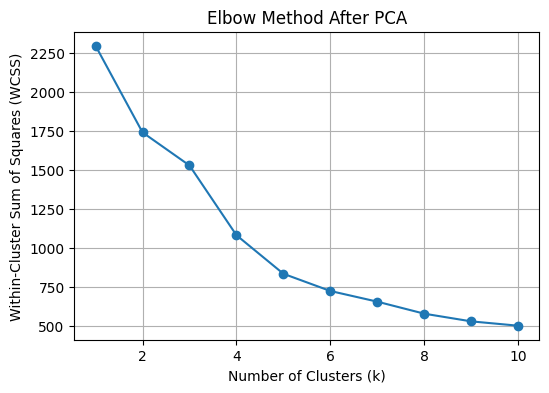

In [29]:
wcss_pca = []

K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(spf500_pca_90_df)
    wcss_pca.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss_pca, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method After PCA")
plt.grid(True)
plt.show()

#Based on PCA elbow curve new K = 3

For Post PCA, I am using k to be both 3 and 4. While the elbow shoes post pca K=3 to be better. The graph is still ambiguous enough for k=4, plus the pre PCA k for K-means was 4, so it might be a good way to see how the model has changed/ evolved.

In [30]:
#Post PCA K=4
kmeans_pca_k4 = KMeans(n_clusters=4, n_init=10, random_state=0)
kmeans_pca_k4.fit(spf500_pca_90_df)

cluster_labels = pd.Series(kmeans_pca_k4.labels_, index= spf500_pca_90_df.index, name='Cluster')
print("Cluster membership:")
for cluster, data in cluster_labels.groupby(cluster_labels):
    print(f"Cluster {cluster}: {', '.join([str(idx) for idx in data.index[:10]])} ...")

centroids = pd.DataFrame(kmeans_pca_k4.cluster_centers_, columns= spf500_pca_90_df.columns)
pd.set_option('display.precision', 3)
print("\nCluster centroids (scaled features):")
display(centroids)


#Distance to centroids see how far each company is from the supposed “center” of its cluster
# A way to see how well the clusters represent the data.
distances = kmeans_pca_k4.transform(spf500_pca_90_df)
min_squared_distances = distances.min(axis=1) ** 2
distance_df = pd.DataFrame({'squaredDistance': min_squared_distances, 'cluster': kmeans_pca_k4.labels_},
                           index=spf500_pca_90_df.index)

# Within-cluster sum of squares
#Adding the squared distances for each cluster to see how tight or spread out the cluster members are
# Another way to see how well the clustering is working.
for cluster, data in distance_df.groupby('cluster'):
    count = len(data)
    within_ss = data.squaredDistance.sum()
    print(f"Cluster {cluster} ({count} members): {within_ss:.2f} within-cluster sum of squares")

Cluster membership:
Cluster 0: 0, 2, 3, 4, 5, 6, 7, 8, 9, 10 ...
Cluster 1: 48, 66, 73, 81, 97, 98, 100, 101, 108, 109 ...
Cluster 2: 1, 37, 96, 196, 215, 216, 223, 307, 341, 384 ...
Cluster 3: 77, 392, 423, 471 ...

Cluster centroids (scaled features):


,PC1,PC2,PC3,PC4
0,1.356,-0.246,-0.226,0.014
1,-0.743,0.043,0.195,0.149
2,1.390,4.039,0.879,-2.743
3,-4.684,-2.710,-7.526,-5.425


Cluster 0 (174 members): 370.93 within-cluster sum of squares
Cluster 1 (314 members): 595.81 within-cluster sum of squares
Cluster 2 (10 members): 58.23 within-cluster sum of squares
Cluster 3 (4 members): 13.48 within-cluster sum of squares


In [46]:
#Post PCA K=3
kmeans_pca_k3 = KMeans(n_clusters=3, n_init=10, random_state=0)
kmeans_pca_k3.fit(spf500_pca_90_df)

cluster_labels = pd.Series(kmeans_pca_k3.labels_, index=spf500_pca_90_df.index, name='Cluster')
print("Cluster membership:")
for cluster, data in cluster_labels.groupby(cluster_labels):
    print(f"Cluster {cluster}: {', '.join([str(idx) for idx in data.index[:10]])} ...")

centroids = pd.DataFrame(kmeans_pca_k3.cluster_centers_, columns=spf500_pca_90_df.columns)
pd.set_option('display.precision', 3)
print("\nCluster centroids (scaled features):")
display(centroids)


#Distance to centroids see how far each company is from the supposed “center” of its cluster
# A way to see how well the clusters represent the data.
distances = kmeans_pca_k3.transform(spf500_pca_90_df)
min_squared_distances = distances.min(axis=1) ** 2
distance_df = pd.DataFrame({'squaredDistance': min_squared_distances, 'cluster': kmeans_pca_k3.labels_},
                           index=spf500_pca_90_df.index)

# Within-cluster sum of squares
#Adding the squared distances for each cluster to see how tight or spread out the cluster members are
# Another way to see how well the clustering is working.
for cluster, data in distance_df.groupby('cluster'):
    count = len(data)
    within_ss = data.squaredDistance.sum()
    print(f"Cluster {cluster} ({count} members): {within_ss:.2f} within-cluster sum of squares")

Cluster membership:
Cluster 0: 81, 97, 98, 101, 109, 115, 117, 126, 136, 137 ...
Cluster 1: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 ...
Cluster 2: 77, 392, 423, 471 ...

Cluster centroids (scaled features):


,PC1,PC2,PC3,PC4
0,-0.756,0.013,0.207,0.152
1,1.335,0.036,-0.179,-0.134
2,-4.684,-2.710,-7.526,-5.425


Cluster 0 (309 members): 575.74 within-cluster sum of squares
Cluster 1 (189 members): 704.66 within-cluster sum of squares
Cluster 2 (4 members): 13.48 within-cluster sum of squares


In [62]:
#Cluster Profiles by Feature/ component
spf500_original_with_k3 = spf500_clean_scaled_df.copy()
spf500_original_with_k3['Cluster_k3'] = kmeans_pca_k3.labels_

spf500_original_with_k4 = spf500_clean_scaled_df.copy()
spf500_original_with_k4['Cluster_k4'] = kmeans_pca_k4.labels_

# Cluster means for k=3
print("Cluster Profiles (Original Features) - K=3")
display(spf500_original_with_k3.groupby('Cluster_k3').mean())

# Cluster means for k=4
print("Cluster Profiles (Original Features) - K-4")
display(spf500_original_with_k4.groupby('Cluster_k4').mean())

Cluster Profiles (Original Features) - K=3


,Log_Marketcap,Signed_Log_Ebitda,Log_Currentprice,Log_Fulltimeemployees,Revenuegrowth
Cluster_k3,,,,,
0,-0.565,-0.027,-0.361,-0.381,-0.213
1,0.934,0.271,0.599,0.624,0.379
2,-0.499,-10.707,-0.406,-0.063,-1.446


Cluster Profiles (Original Features) - K-4


,Log_Marketcap,Signed_Log_Ebitda,Log_Currentprice,Log_Fulltimeemployees,Revenuegrowth
Cluster_k4,,,,,
0,0.961,0.289,0.651,0.732,0.072
1,-0.541,-0.030,-0.347,-0.402,-0.185
2,0.447,0.200,-0.278,-0.100,5.132
3,-0.499,-10.707,-0.406,-0.063,-1.446


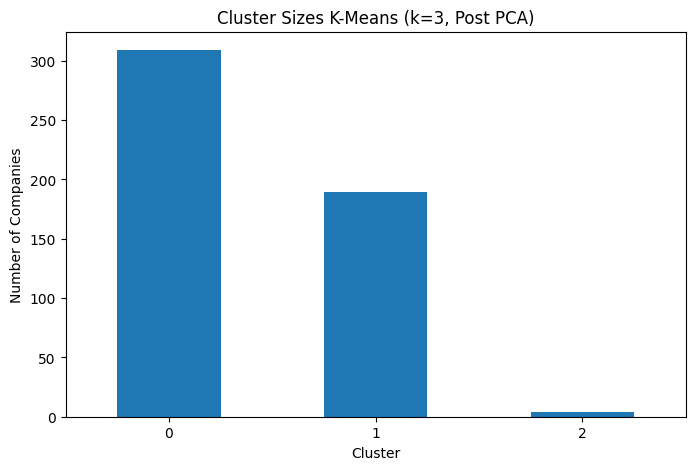

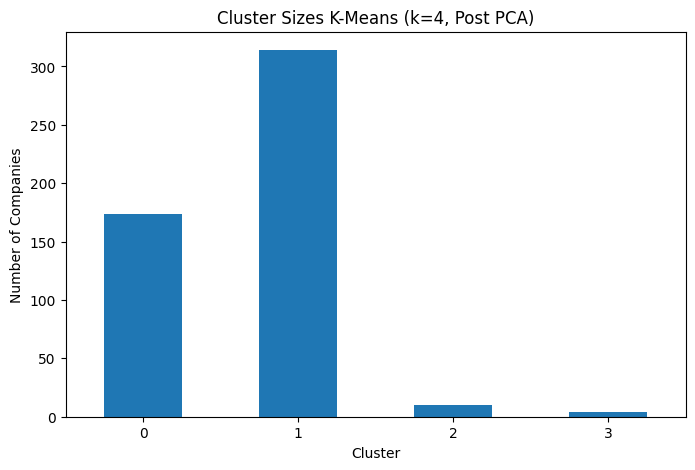

In [63]:
#Cluster Size

# Cluster Sizes for K=3 (Post-PCA K-Means)
plt.figure(figsize=(8, 5))
spf500_original_with_k3['Cluster_k3'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Sizes K-Means (k=3, Post PCA)")
plt.xlabel("Cluster")
plt.ylabel("Number of Companies")
plt.xticks(rotation=0)
plt.show()


# Cluster Sizes for K=4 (Post-PCA K-Means)
plt.figure(figsize=(8, 5))
spf500_original_with_k4['Cluster_k4'].value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Sizes K-Means (k=4, Post PCA)")
plt.xlabel("Cluster")
plt.ylabel("Number of Companies")
plt.xticks(rotation=0)
plt.show()

### Cluster Profiling: Post-PCA K-Means (k=4)

In [50]:

cleaned_spf500_df_with_k4_post_pca = cleaned_spf500_df.copy()
cleaned_spf500_df_with_k4_post_pca['Cluster_k4_PostPCA'] = kmeans_pca_k4.labels_

print("DataFrame with Post-PCA K-Means (k=4) Cluster Labels head:")
display(cleaned_spf500_df_with_k4_post_pca.head())

DataFrame with Post-PCA K-Means (k=4) Cluster Labels head:


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Log_Marketcap,Log_Currentprice,Log_Fulltimeemployees,Signed_Log_Ebitda,Cluster_k4_PostPCA
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.347e+11,0.061,1.640e+05,28.978,5.543,12.008,25.626,0
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118e+10,1.224,2.960e+04,28.825,4.910,10.296,24.837,2
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.366e+11,0.160,2.280e+05,28.808,6.081,12.337,25.640,0
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.116e+11,0.110,1.551e+06,28.492,5.420,14.254,25.438,0
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.235e+11,0.151,1.813e+05,28.486,5.260,12.108,25.539,0


#### Sector Distribution (Post-PCA K-Means, k=4)


Sector Distribution per Cluster (Post-PCA K-Means, k=4 - Top 5):

Cluster 0:


,Cluster_k4_PostPCA,Sector,Percentage
0,0,Technology,19.540
1,0,Industrials,17.241
2,0,Financial Services,16.667
3,0,Healthcare,16.667
4,0,Consumer Cyclical,10.920



Cluster 1:


,Cluster_k4_PostPCA,Sector,Percentage
11,1,Technology,14.331
12,1,Industrials,12.420
13,1,Consumer Cyclical,11.146
14,1,Financial Services,10.510
15,1,Healthcare,10.191



Cluster 2:


,Cluster_k4_PostPCA,Sector,Percentage
22,2,Financial Services,40.0
23,2,Technology,30.0
24,2,Basic Materials,10.0
25,2,Consumer Cyclical,10.0
26,2,Utilities,10.0



Cluster 3:


,Cluster_k4_PostPCA,Sector,Percentage
27,3,Basic Materials,25.0
28,3,Financial Services,25.0
29,3,Healthcare,25.0
30,3,Industrials,25.0


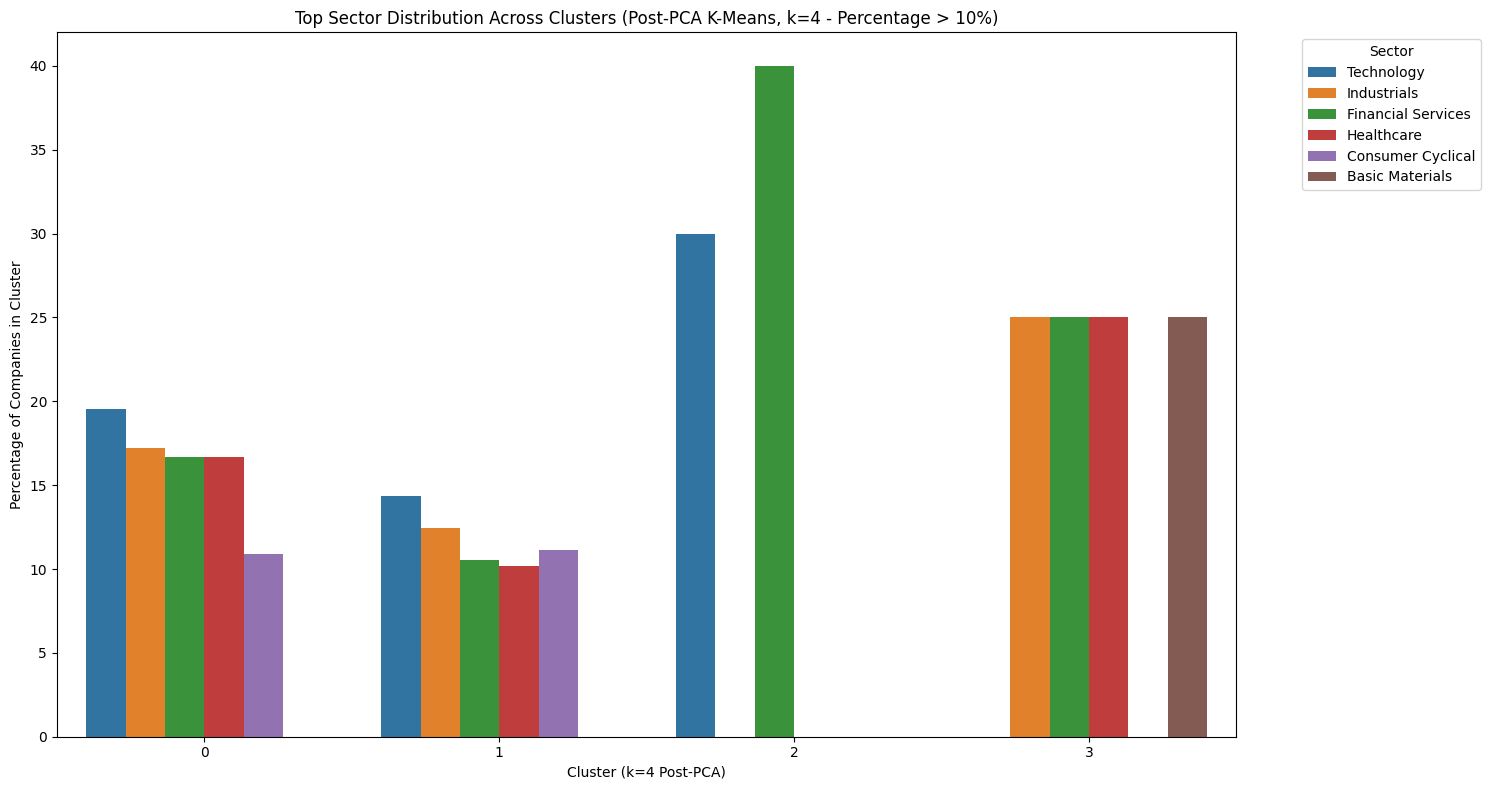

In [69]:
print("\nSector Distribution per Cluster (Post-PCA K-Means, k=4 - Top 5):")
sector_profiling_k4_post_pca = cleaned_spf500_df_with_k4_post_pca.groupby('Cluster_k4_PostPCA')['Sector'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_k4_post_pca['Cluster_k4_PostPCA'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(sector_profiling_k4_post_pca[sector_profiling_k4_post_pca['Cluster_k4_PostPCA'] == cluster_id].head(5))

plt.figure(figsize=(15, 8))
sns.barplot(data=sector_profiling_k4_post_pca[sector_profiling_k4_post_pca['Percentage'] > 10], x='Cluster_k4_PostPCA', y='Percentage', hue='Sector', palette='tab10')
plt.title('Top Sector Distribution Across Clusters (Post-PCA K-Means, k=4 - Percentage > 10%)')
plt.xlabel('Cluster (k=4 Post-PCA)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Industry Distribution (Post-PCA K-Means, k=4)


Industry Distribution per Cluster (Post-PCA K-Means, k=4 - Top 5):

Cluster 0:


,Cluster_k4_PostPCA,Industry,Percentage
0,0,Software - Application,5.172
1,0,Drug Manufacturers - General,4.598
2,0,Aerospace & Defense,4.023
3,0,Semiconductors,3.448
4,0,Software - Infrastructure,3.448



Cluster 1:


,Cluster_k4_PostPCA,Industry,Percentage
66,1,Utilities - Regulated Electric,6.369
67,1,Specialty Industrial Machinery,3.503
68,1,Oil & Gas E&P,3.185
69,1,Packaged Foods,2.866
70,1,Banks - Regional,2.548



Cluster 2:


,Cluster_k4_PostPCA,Industry,Percentage
168,2,Semiconductors,20.0
169,2,Asset Management,10.0
170,2,Computer Hardware,10.0
171,2,Credit Services,10.0
172,2,Gold,10.0



Cluster 3:


,Cluster_k4_PostPCA,Industry,Percentage
177,3,Aerospace & Defense,25.0
178,3,Asset Management,25.0
179,3,Biotechnology,25.0
180,3,Specialty Chemicals,25.0


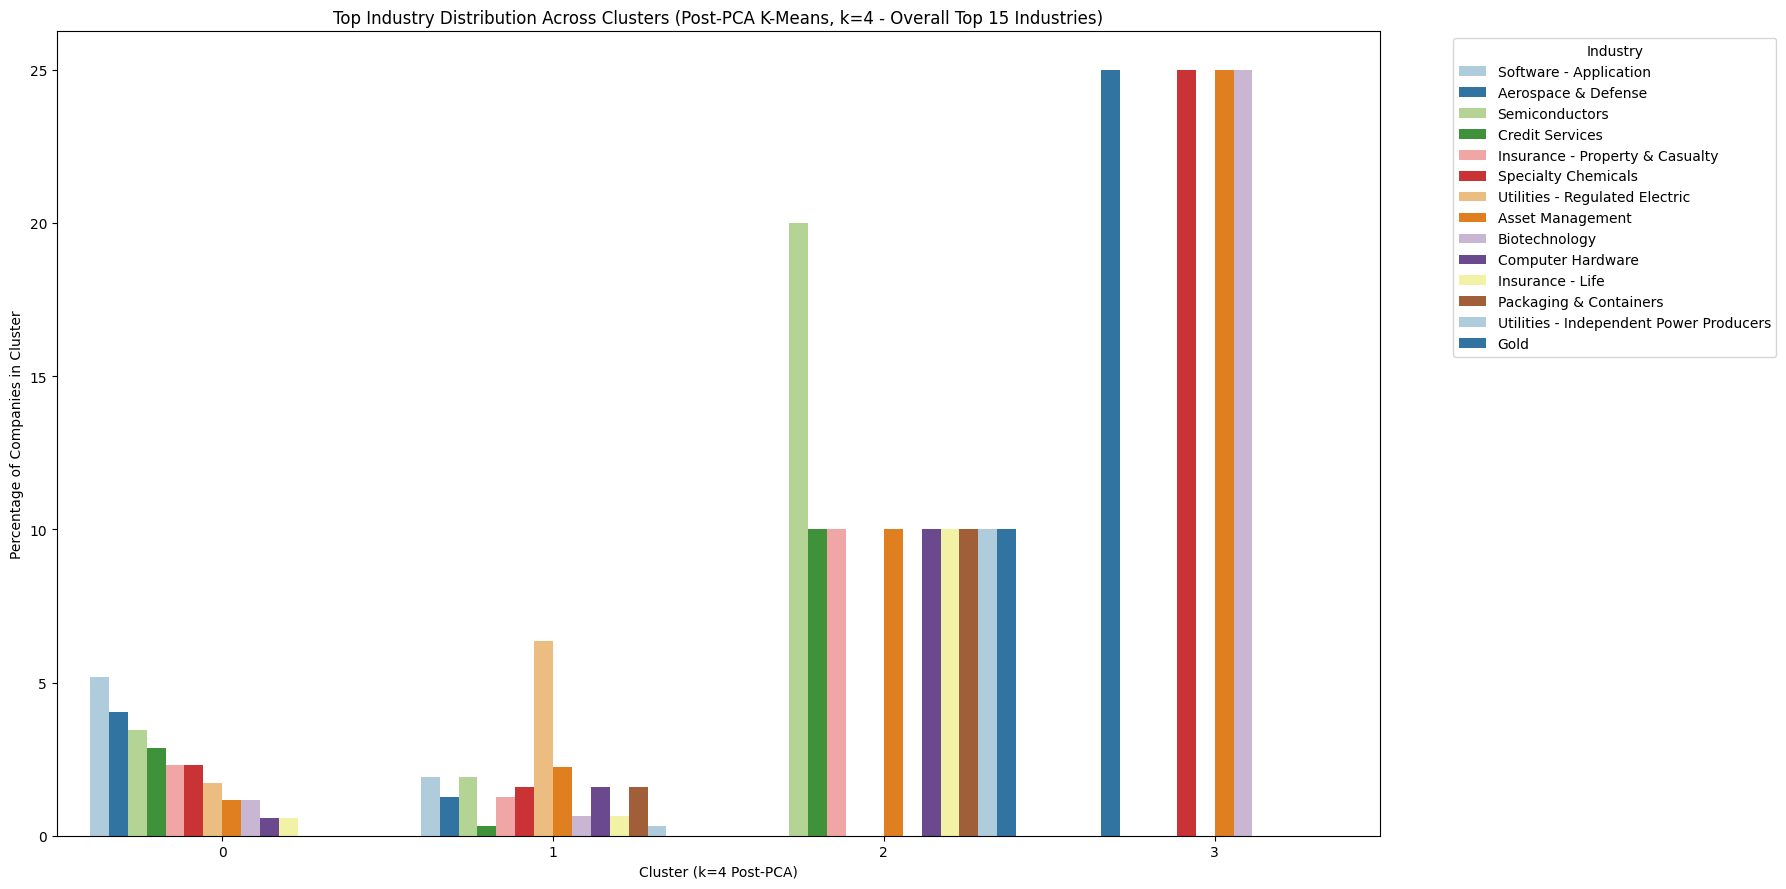

In [67]:
print("\nIndustry Distribution per Cluster (Post-PCA K-Means, k=4 - Top 5):")
industry_profiling_k4_post_pca = cleaned_spf500_df_with_k4_post_pca.groupby('Cluster_k4_PostPCA')['Industry'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_k4_post_pca['Cluster_k4_PostPCA'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(industry_profiling_k4_post_pca[industry_profiling_k4_post_pca['Cluster_k4_PostPCA'] == cluster_id].head(5))

# Visualize top industries per cluster
top_industries_k4_post_pca = industry_profiling_k4_post_pca.nlargest(15, 'Percentage')['Industry'].unique()
plt.figure(figsize=(18, 9))
sns.barplot(data=industry_profiling_k4_post_pca[industry_profiling_k4_post_pca['Industry'].isin(top_industries_k4_post_pca)], x='Cluster_k4_PostPCA', y='Percentage', hue='Industry', palette='Paired')
plt.title('Top Industry Distribution Across Clusters (Post-PCA K-Means, k=4 - Overall Top 15 Industries)')
plt.xlabel('Cluster (k=4 Post-PCA)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Cluster Profiling: Post-PCA K-Means (k=3)

In [53]:
final_k3_labels = kmeans_pca_k3.labels_
cleaned_spf500_df_with_clusters = cleaned_spf500_df.copy()
cleaned_spf500_df_with_clusters['Cluster_k3'] = final_k3_labels

print("DataFrame with Cluster Labels head:")
display(cleaned_spf500_df_with_clusters.head())

DataFrame with Cluster Labels head:


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Log_Marketcap,Log_Currentprice,Log_Fulltimeemployees,Signed_Log_Ebitda,Cluster_k3
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.347e+11,0.061,1.640e+05,28.978,5.543,12.008,25.626,1
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118e+10,1.224,2.960e+04,28.825,4.910,10.296,24.837,1
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.366e+11,0.160,2.280e+05,28.808,6.081,12.337,25.640,1
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.116e+11,0.110,1.551e+06,28.492,5.420,14.254,25.438,1
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.235e+11,0.151,1.813e+05,28.486,5.260,12.108,25.539,1


#### Sector Distribution (Post-PCA K-Means, k=3)


Sector Distribution per Cluster (Post-PCA K-Means, k=3 - Top 5):

Cluster 0:


,Cluster_k3,Sector,Percentage
0,0,Technology,13.269
1,0,Industrials,12.945
2,0,Consumer Cyclical,11.327
3,0,Healthcare,10.356
4,0,Financial Services,10.032



Cluster 1:


,Cluster_k3,Sector,Percentage
11,1,Technology,21.693
12,1,Financial Services,18.519
13,1,Healthcare,15.344
14,1,Industrials,15.344
15,1,Consumer Cyclical,10.582



Cluster 2:


,Cluster_k3,Sector,Percentage
22,2,Basic Materials,25.0
23,2,Financial Services,25.0
24,2,Healthcare,25.0
25,2,Industrials,25.0


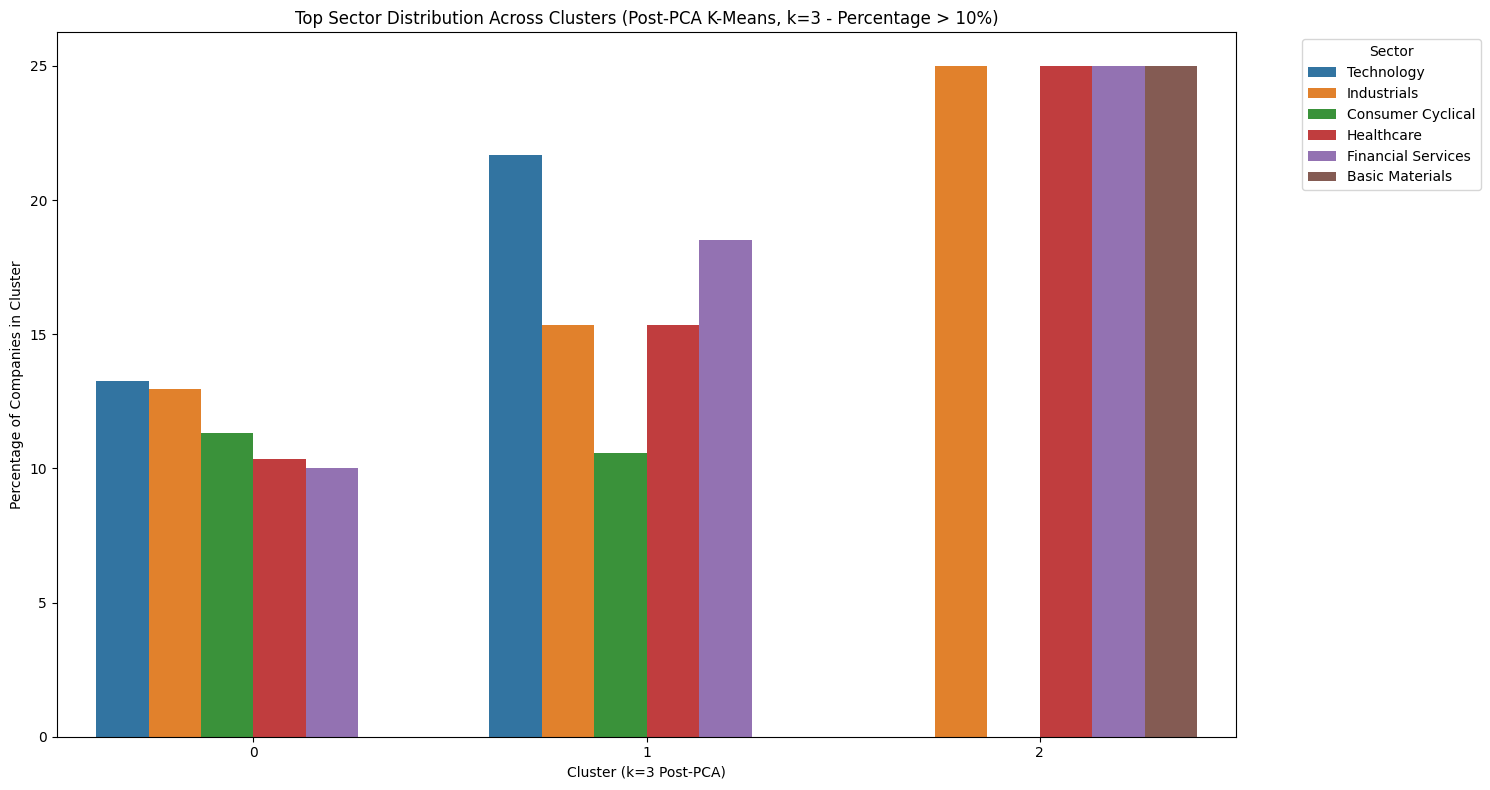

In [54]:

print("\nSector Distribution per Cluster (Post-PCA K-Means, k=3 - Top 5):")
sector_profiling = cleaned_spf500_df_with_clusters.groupby('Cluster_k3')['Sector'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_clusters['Cluster_k3'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(sector_profiling[sector_profiling['Cluster_k3'] == cluster_id].head(5))


plt.figure(figsize=(15, 8))
sns.barplot(data=sector_profiling[sector_profiling['Percentage'] > 10], x='Cluster_k3', y='Percentage', hue='Sector', palette='tab10')
plt.title('Top Sector Distribution Across Clusters (Post-PCA K-Means, k=3 - Percentage > 10%)')
plt.xlabel('Cluster (k=3 Post-PCA)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Industry Distribution (Post-PCA K-Means, k=3)


Industry Distribution per Cluster (Post-PCA K-Means, k=3 - Top 5):

Cluster 0:


,Cluster_k3,Industry,Percentage
0,0,Utilities - Regulated Electric,6.472
1,0,Specialty Industrial Machinery,3.560
2,0,Oil & Gas E&P,3.236
3,0,Packaged Foods,2.913
4,0,Banks - Regional,2.589



Cluster 1:


,Cluster_k3,Industry,Percentage
102,1,Software - Application,4.762
103,1,Aerospace & Defense,4.233
104,1,Drug Manufacturers - General,4.233
105,1,Semiconductors,4.233
106,1,Software - Infrastructure,3.704



Cluster 2:


,Cluster_k3,Industry,Percentage
171,2,Aerospace & Defense,25.0
172,2,Asset Management,25.0
173,2,Biotechnology,25.0
174,2,Specialty Chemicals,25.0


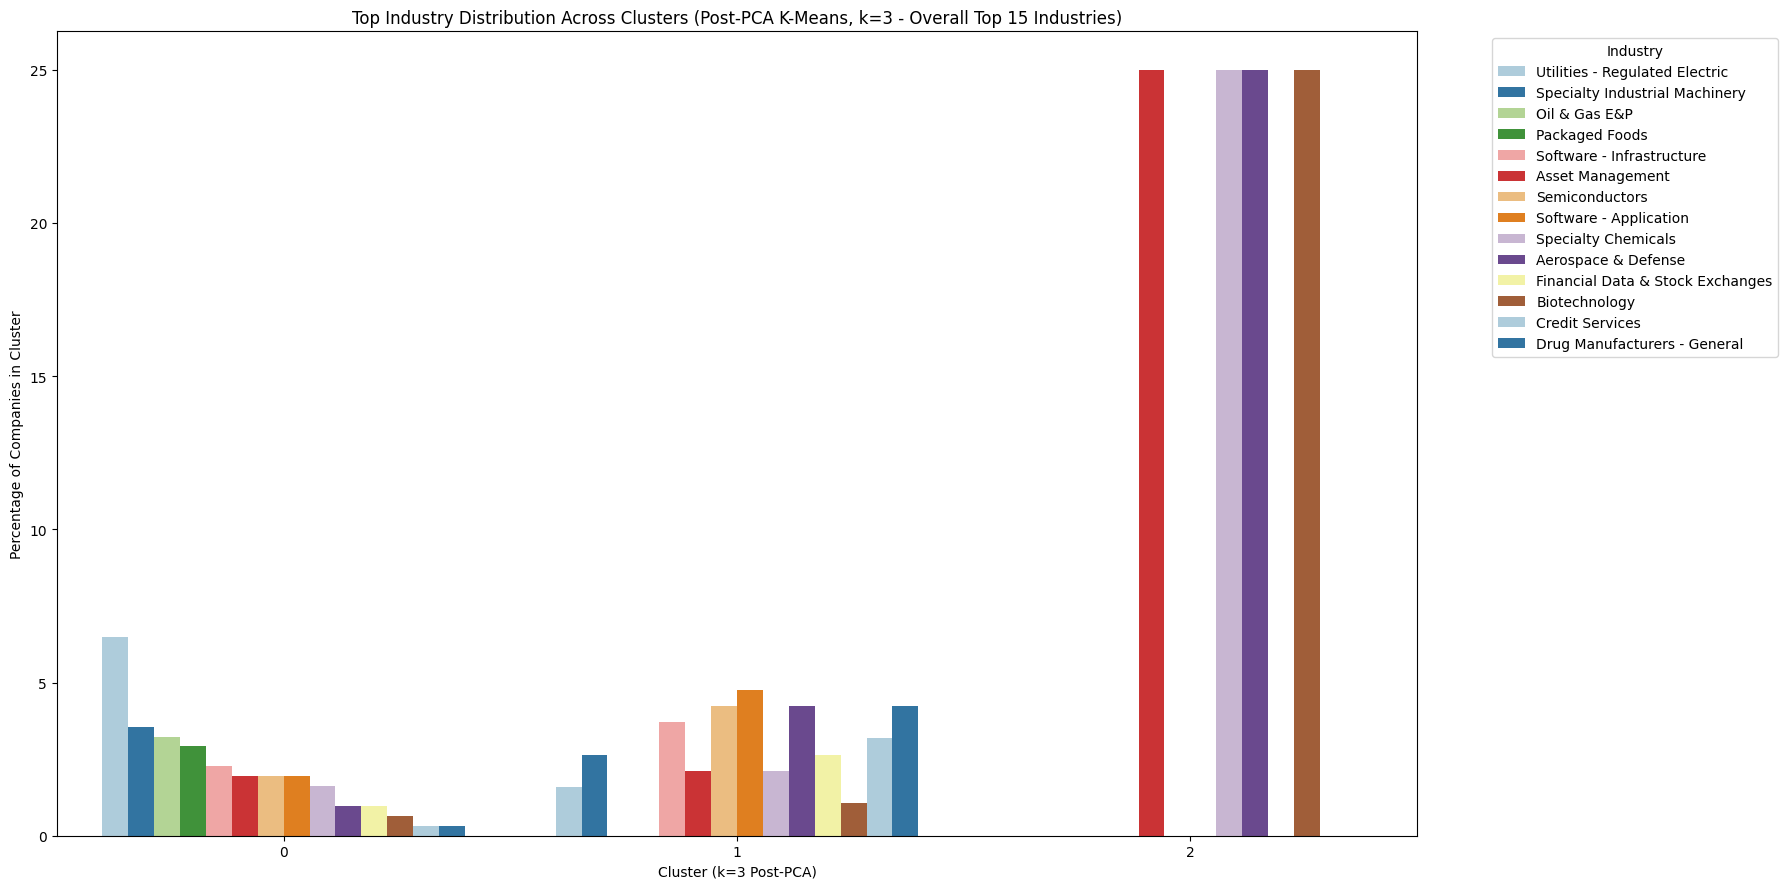

In [55]:

print("\nIndustry Distribution per Cluster (Post-PCA K-Means, k=3 - Top 5):")
industry_profiling = cleaned_spf500_df_with_clusters.groupby('Cluster_k3')['Industry'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_clusters['Cluster_k3'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(industry_profiling[industry_profiling['Cluster_k3'] == cluster_id].head(5))


top_industries = industry_profiling.nlargest(15, 'Percentage')['Industry'].unique()
plt.figure(figsize=(18, 9))
sns.barplot(data=industry_profiling[industry_profiling['Industry'].isin(top_industries)], x='Cluster_k3', y='Percentage', hue='Industry', palette='Paired')
plt.title('Top Industry Distribution Across Clusters (Post-PCA K-Means, k=3 - Overall Top 15 Industries)')
plt.xlabel('Cluster (k=3 Post-PCA)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

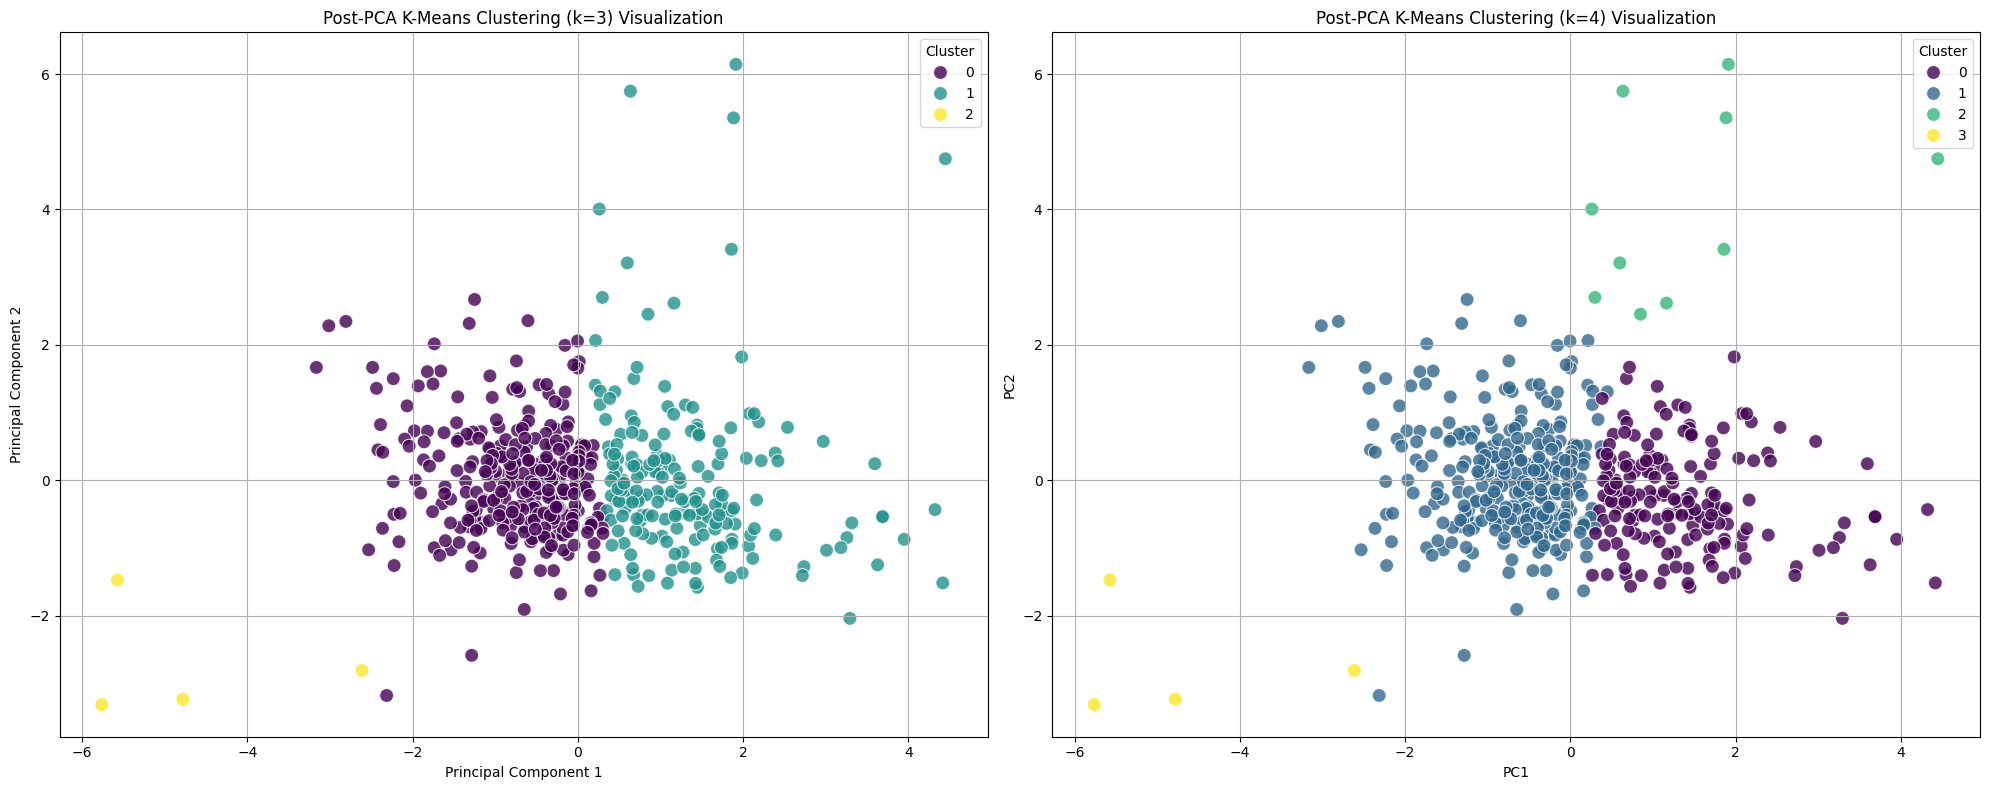

In [78]:
#K3vs K4 scatter Plot

#k3
pca_k3_df = spf500_pca_90_df.copy()
pca_k3_df['Cluster'] = kmeans_pca_k3.labels_

#k4
pca_k4_df = spf500_pca_90_df.copy()
pca_k4_df['Cluster'] = kmeans_pca_k4.labels_

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot k=3
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=pca_k3_df,
    palette='viridis', s=100, alpha=0.8, legend='full', ax=axes[0]
)
axes[0].set_title('Post-PCA K-Means Clustering (k=3) Visualization')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True)

# Plot k=4
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=pca_k4_df,
    palette='viridis', s=100, alpha=0.8, legend='full', ax=axes[1]
)
axes[1].set_title('Post-PCA K-Means Clustering (k=4) Visualization')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Hierarchial Clustering (Post PCA)

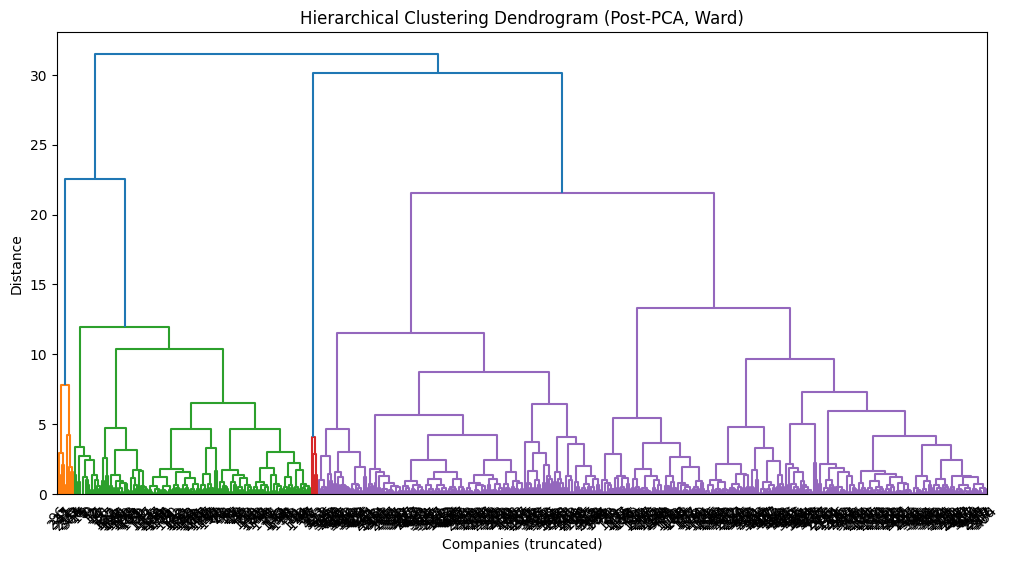

In [81]:
Z_pca = linkage(spf500_pca_90_df, method='ward')

plt.figure(figsize=(12, 6))
plt.title('Hierarchical Clustering Dendrogram (Post-PCA, Ward)')
dendrogram(Z_pca, truncate_mode='level', p=30, leaf_rotation=45, leaf_font_size=10)
plt.xlabel('Companies (truncated)')
plt.ylabel('Distance')
plt.show()

#based on this dendogram, K=2

In [79]:
# Cluster labelling for k=2
hc_labels = fcluster(Z_pca, 2, criterion='maxclust')
hc_membership = pd.Series(hc_labels, index=spf500_pca_90_df.index, name='Cluster')

for key, item in hc_membership.groupby(hc_membership):
    print(f"Cluster {key}: {', '.join(map(str, item.index))}")

# Cluster centroids
hc_centroids = spf500_pca_90_df.groupby(hc_membership).mean()
pd.set_option('display.precision', 3)
print("\nHierarchical cluster centroids (Post PCA)")
display(hc_centroids)

# Within cluster sum of squares
distances = pairwise.pairwise_distances(spf500_pca_90_df, hc_centroids.loc[hc_membership])
min_squared_distances = distances.min(axis=1) ** 2
distance_df = pd.DataFrame({'squaredDistance': min_squared_distances, 'cluster': hc_membership},
                           index=spf500_pca_90_df.index)

for cluster, data in distance_df.groupby('cluster'):
    count = len(data)
    within_ss = data.squaredDistance.sum()
    print(f"Cluster {cluster} ({count} members): {within_ss:.2f} within-cluster sum of squares")

Cluster 1: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 49, 50, 51, 52, 53, 54, 56, 57, 59, 60, 61, 62, 63, 67, 68, 69, 70, 71, 75, 76, 82, 83, 84, 85, 87, 90, 93, 95, 96, 99, 103, 106, 107, 111, 112, 113, 116, 119, 120, 121, 124, 125, 127, 128, 129, 130, 131, 132, 133, 134, 138, 139, 140, 141, 142, 143, 146, 147, 148, 149, 151, 152, 153, 156, 157, 158, 161, 170, 177, 178, 181, 182, 185, 186, 187, 190, 193, 194, 197, 199, 211, 215, 216, 223, 227, 243, 254, 271, 288, 307, 322, 341, 384
Cluster 2: 23, 26, 30, 31, 48, 55, 58, 64, 65, 66, 72, 73, 74, 77, 78, 79, 80, 81, 86, 88, 89, 91, 92, 94, 97, 98, 100, 101, 102, 104, 105, 108, 109, 110, 114, 115, 117, 118, 122, 123, 126, 135, 136, 137, 144, 145, 150, 154, 155, 159, 160, 162, 163, 164, 165, 166, 167, 168, 169, 171, 172, 173, 174, 175, 176, 179, 180, 183, 184, 188, 189, 191, 192, 195, 196, 198, 200, 201, 202, 203, 204,

,PC1,PC2,PC3,PC4
Cluster,,,,
1,1.572,0.166,-0.358,-0.053
2,-0.590,-0.062,0.134,0.020


Cluster 1 (137 members): 550.18 within-cluster sum of squares
Cluster 2 (365 members): 1213.79 within-cluster sum of squares


CLuster Profiling

In [70]:

cleaned_spf500_df_with_hc2_post_pca = cleaned_spf500_df.copy()
cleaned_spf500_df_with_hc2_post_pca['Cluster_k2_PostPCA_HC'] = hc_membership

print("DataFrame with Post-PCA Hierarchical (k=2) Cluster Labels head:")
display(cleaned_spf500_df_with_hc2_post_pca.head())

DataFrame with Post-PCA Hierarchical (k=2) Cluster Labels head:


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Log_Marketcap,Log_Currentprice,Log_Fulltimeemployees,Signed_Log_Ebitda,Cluster_k2_PostPCA_HC
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.347e+11,0.061,1.640e+05,28.978,5.543,12.008,25.626,1
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118e+10,1.224,2.960e+04,28.825,4.910,10.296,24.837,1
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.366e+11,0.160,2.280e+05,28.808,6.081,12.337,25.640,1
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.116e+11,0.110,1.551e+06,28.492,5.420,14.254,25.438,1
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.235e+11,0.151,1.813e+05,28.486,5.260,12.108,25.539,1


Sector Profiling Post Agg Hierarchical Clustering K=2


Sector Distribution per Cluster (Post-PCA Hierarchical, k=2 - Top 5):

Cluster 1:


,Cluster_k2_PostPCA_HC,Sector,Percentage
0,1,Technology,20.438
1,1,Financial Services,18.978
2,1,Industrials,17.518
3,1,Healthcare,16.788
4,1,Consumer Cyclical,10.219



Cluster 2:


,Cluster_k2_PostPCA_HC,Sector,Percentage
11,2,Technology,14.795
12,2,Industrials,12.603
13,2,Consumer Cyclical,11.233
14,2,Financial Services,11.233
15,2,Healthcare,10.685


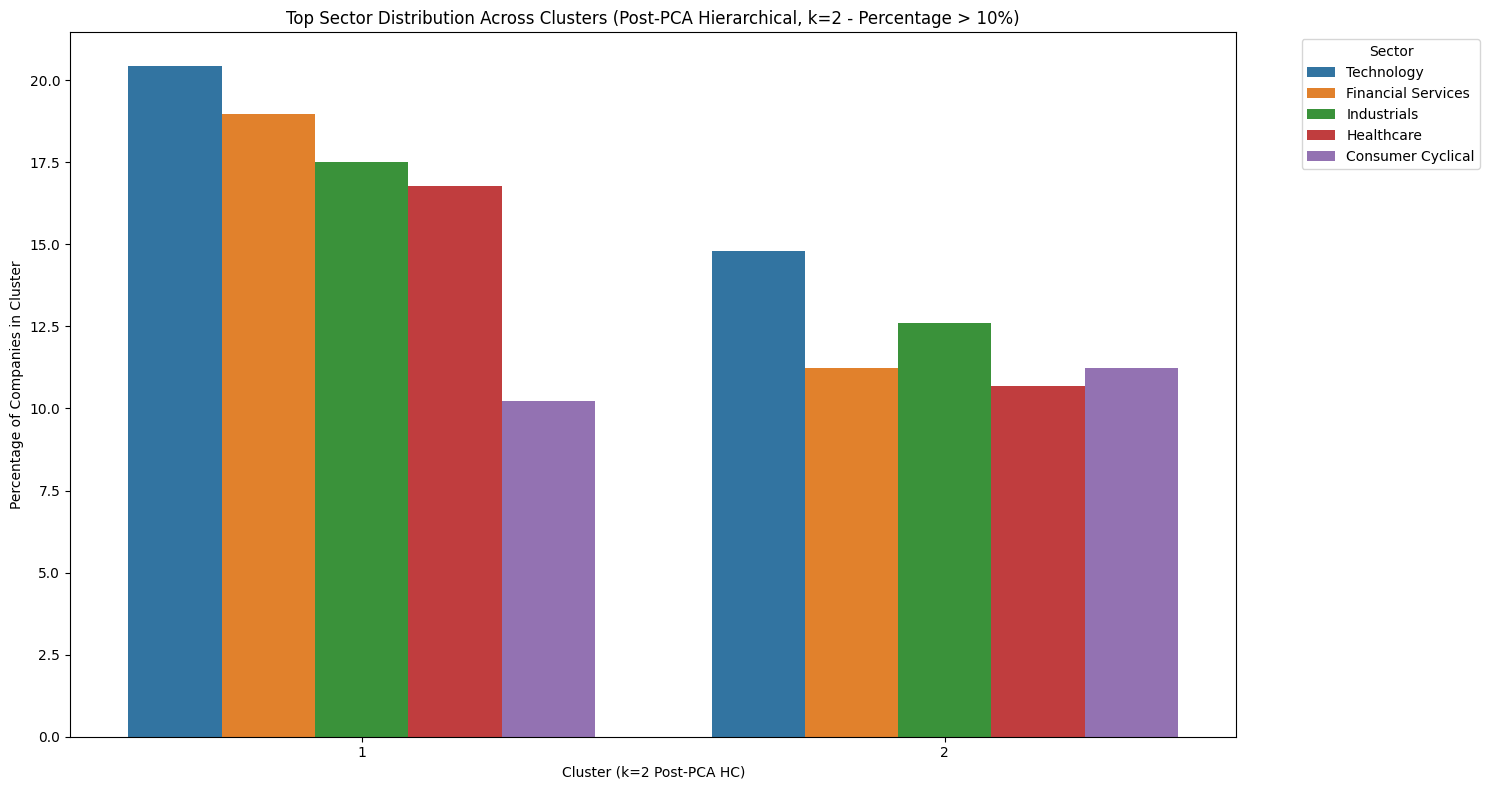

In [71]:
print("\nSector Distribution per Cluster (Post-PCA Hierarchical, k=2 - Top 5):")
sector_profiling_hc2_post_pca = cleaned_spf500_df_with_hc2_post_pca.groupby('Cluster_k2_PostPCA_HC')['Sector'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_hc2_post_pca['Cluster_k2_PostPCA_HC'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(sector_profiling_hc2_post_pca[sector_profiling_hc2_post_pca['Cluster_k2_PostPCA_HC'] == cluster_id].head(5))


plt.figure(figsize=(15, 8))
sns.barplot(data=sector_profiling_hc2_post_pca[sector_profiling_hc2_post_pca['Percentage'] > 10], x='Cluster_k2_PostPCA_HC', y='Percentage', hue='Sector', palette='tab10')
plt.title('Top Sector Distribution Across Clusters (Post-PCA Hierarchical, k=2 - Percentage > 10%)')
plt.xlabel('Cluster (k=2 Post-PCA HC)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Post PCA Agg Hierarchical Clustering K=2


Industry Distribution per Cluster (Post-PCA Hierarchical, k=2 - Top 5):

Cluster 1:


,Cluster_k2_PostPCA_HC,Industry,Percentage
0,1,Software - Application,5.839
1,1,Aerospace & Defense,5.109
2,1,Drug Manufacturers - General,4.380
3,1,Semiconductors,4.380
4,1,Credit Services,3.650



Cluster 2:


,Cluster_k2_PostPCA_HC,Industry,Percentage
61,2,Utilities - Regulated Electric,6.301
62,2,Specialty Industrial Machinery,3.288
63,2,Oil & Gas E&P,2.740
64,2,Packaged Foods,2.466
65,2,Software - Infrastructure,2.466


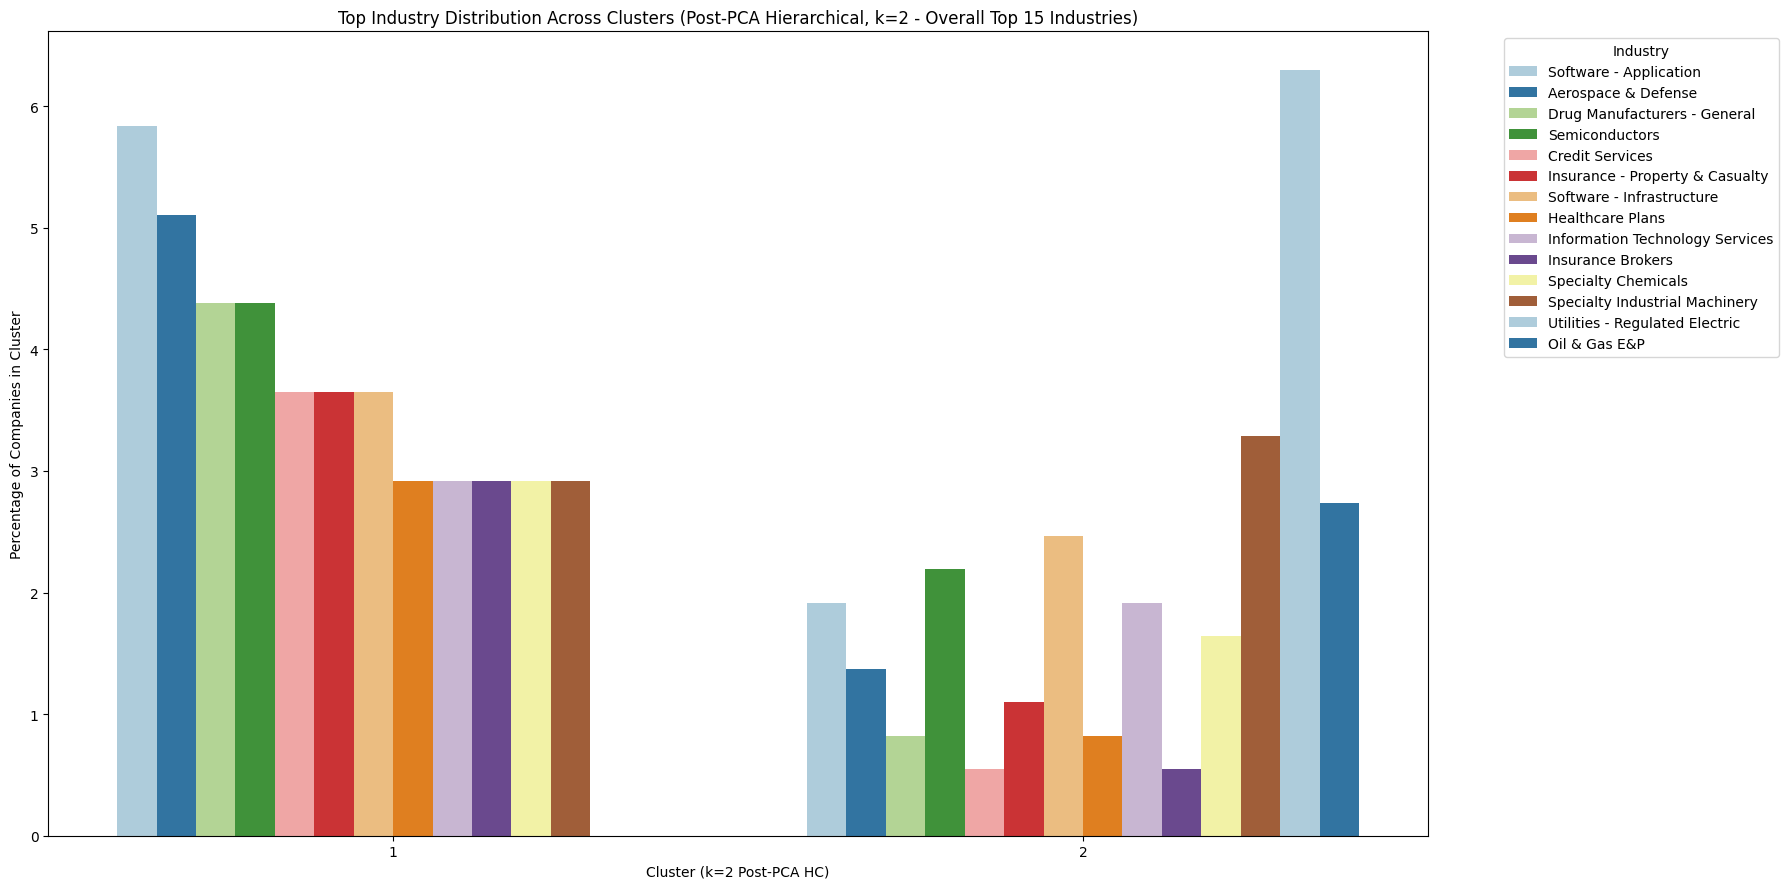

In [72]:
print("\nIndustry Distribution per Cluster (Post-PCA Hierarchical, k=2 - Top 5):")
industry_profiling_hc2_post_pca = cleaned_spf500_df_with_hc2_post_pca.groupby('Cluster_k2_PostPCA_HC')['Industry'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
for cluster_id in sorted(cleaned_spf500_df_with_hc2_post_pca['Cluster_k2_PostPCA_HC'].unique()):
    print(f"\nCluster {cluster_id}:")
    display(industry_profiling_hc2_post_pca[industry_profiling_hc2_post_pca['Cluster_k2_PostPCA_HC'] == cluster_id].head(5))

# Visualize top industries per cluster
top_industries_hc2_post_pca = industry_profiling_hc2_post_pca.nlargest(15, 'Percentage')['Industry'].unique()
plt.figure(figsize=(18, 9))
sns.barplot(data=industry_profiling_hc2_post_pca[industry_profiling_hc2_post_pca['Industry'].isin(top_industries_hc2_post_pca)], x='Cluster_k2_PostPCA_HC', y='Percentage', hue='Industry', palette='Paired')
plt.title('Top Industry Distribution Across Clusters (Post-PCA Hierarchical, k=2 - Overall Top 15 Industries)')
plt.xlabel('Cluster (k=2 Post-PCA HC)')
plt.ylabel('Percentage of Companies in Cluster')
plt.xticks(rotation=0)
plt.legend(title='Industry', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

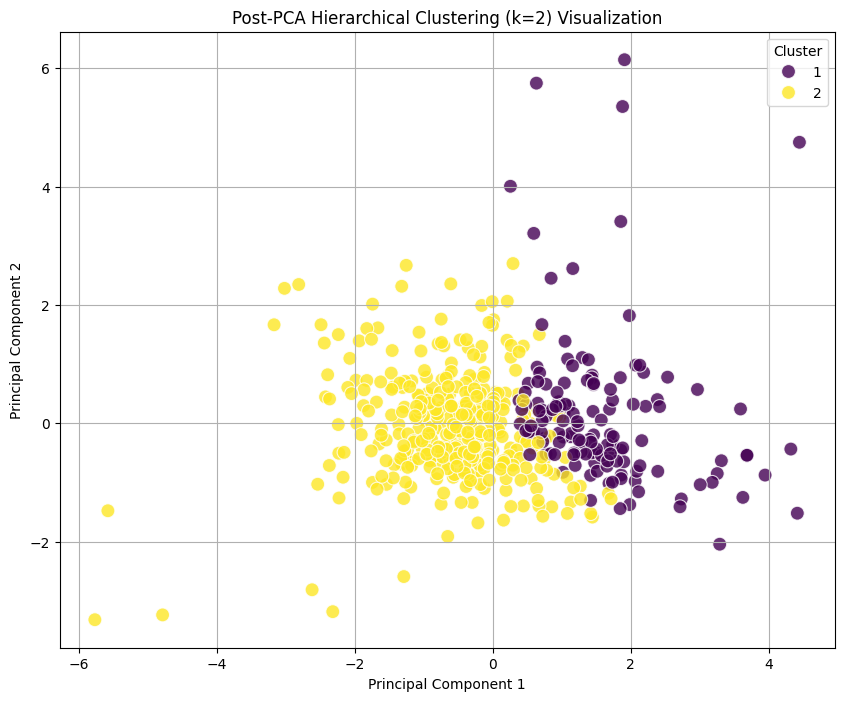

In [77]:
#AGG Hierarchcial Post PCA scatter
pca_hc_df = spf500_pca_90_df.copy()
pca_hc_df['Cluster'] = hc_membership

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster', data=pca_hc_df,
    palette='viridis', s=100, alpha=0.8, legend='full'
)
plt.title('Post-PCA Hierarchical Clustering (k=2) Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Academic Integrity


*   The code present in this Notebook was at times created with the help of embedded Gemini interms of auto-completetion or when I faced errors. It also helped me code some ideas like the Profile clustering seen here


*   The code present here also has direct copy-paste code from classs lectures and some homework assignments that were then either left as is or modified with respect to my data set.
*   Some code here was also derived from Substack


*   However, all interpretations and Analyses derived from this notebook in the project report are my original work







